#### Configuration

In [1]:
import os
import pickle

In [ ]:
from methyldl.data import CELL_TYPE_MATCH_DICT as cell_type_match_dict
from methyldl.data.bam_processing import *
from methyldl.data.preprocessing import *
from methyldl.data.pseudo_bulk_generation import *
from methyldl.data.genome import *
from methyldl.deconvolution.uxm import *
from methyldl.inference.prediction_aggregation import *
from methyldl.visualization.kde_plotting import *
from methyldl.visualization.bland_altman_analysis import *
from methyldl.visualization.methylation_plotting import *
from methyldl.visualization.predictions_plotting import *
from methyldl.deconvolution.training import *
from methyldl.deconvolution.flatten_mlp_deconvolver import *
from methyldl.deconvolution.dmr_attention_deconvolver import *
from methyldl.deconvolution.diagonal_aware_deconvolver import *
from methyldl.deconvolution.cnn_deconvolver import *

reads_data_path = "/home/luna.kuleuven.be/u0169940/Data/Loyfer/TrainingDataWithRejection_hg38_mincpg_4_minlen_10/"
dmr_label_column = "dmr_ctype_label"
mincpg_pointer = reads_data_path.find("mincpg_")
classifier_model_path = f"../Tutorials/methylBertLoyferWithReject_attentionClassifier_DMRs_stratified_hg38_{dmr_label_column}_{reads_data_path[mincpg_pointer:]}"
mincpg = int(reads_data_path[mincpg_pointer + 7 : mincpg_pointer + 8])
features_encoding = "extracted_numpy"

#### Extract features from IOs

In [ ]:
# def _extract_diag_and_rej(matrix):
#     return np.reshape(np.concat([np.diag(matrix), matrix[:, -1]], axis=0), (1,78))

In [ ]:
# proportions_list = []
# features_train_list = []
# features_valid_list = []
# features_test_list = []
# pred_cols = [f"prediction_{i}_wavg" for i in range(40)]

# for ios in tqdm(os.listdir(os.path.join(classifier_model_path, "ios_deconvolution"))):
#     with open(os.path.join(classifier_model_path, "ios_deconvolution", ios), "rb") as f:
#         part_ios = pickle.load(f)

#     for i in range(len(part_ios)):
#         gt = np.reshape(part_ios[i][0], (1, 39))
#         f_tr = _extract_diag_and_rej(part_ios[i][1][0][pred_cols].to_numpy())
#         f_val = _extract_diag_and_rej(part_ios[i][1][1][pred_cols].to_numpy())
#         f_tst = _extract_diag_and_rej(part_ios[i][1][2][pred_cols].to_numpy())

#         features_train_list.append(f_tr)
#         features_valid_list.append(f_val)
#         features_test_list.append(f_tst)
#         proportions_list.append(gt)

# # Single concatenation at the end (O(n))
# proportions = np.concatenate(proportions_list, axis=0)
# features_train = np.concatenate(features_train_list, axis=0)
# features_valid = np.concatenate(features_valid_list, axis=0)
# features_test = np.concatenate(features_test_list, axis=0)

100%|██████████| 281/281 [21:47<00:00,  4.65s/it]


In [ ]:
# np.savez_compressed(
#     os.path.join(classifier_model_path, 'features.npz'),
#     proportions=proportions,
#     features_train=features_train,
#     features_valid=features_valid,
#     features_test=features_test
# )

#### Train the model

In [3]:
model_checkpoint = [x for x in os.listdir(classifier_model_path) if "checkpoint" in x][
    0
]
fine_tuned_model_path = os.path.join(
    classifier_model_path, model_checkpoint, "model.safetensors"
)

In [4]:
with open(
    f"{classifier_model_path}/methylbert_deconv_prepared_splits_hg38.pkl", "rb"
) as f:
    train_split_uxm_input, valid_split_uxm_input, test_split_uxm_input = pickle.load(f)

In [5]:
if features_encoding != "extracted_numpy":
    with open(
        f"{classifier_model_path}/ios_deconvolution_data_hg38_grouped_dmrs_uxm_alligned.pkl",
        "rb",
    ) as f:
        all_ios = pickle.load(f)
    train_features = np.array(
        [
            np.array(all_ios[k][1][0][[f"prediction_{i}_wavg" for i in range(40)]])
            for k in range(len(all_ios))
        ]
    )
    valid_features = np.array(
        [
            np.array(all_ios[k][1][1][[f"prediction_{i}_wavg" for i in range(40)]])
            for k in range(len(all_ios))
        ]
    )
    test_features = np.array(
        [
            np.array(all_ios[k][1][2][[f"prediction_{i}_wavg" for i in range(40)]])
            for k in range(len(all_ios))
        ]
    )
    train_outputs = valid_outputs = test_outputs = np.array(
        [np.array(all_ios[k][0]) for k in range(len(all_ios))]
    )
else:
    data = np.load(os.path.join(classifier_model_path, "features.npz"))
    train_features = data["features_train"]
    valid_features = data["features_valid"]
    test_features = data["features_test"]
    train_outputs = valid_outputs = test_outputs = data["proportions"]

In [87]:
os.path.join(classifier_model_path, "features.npz")

'../Tutorials/methylBertLoyferWithReject_attentionClassifier_DMRs_stratified_hg38_dmr_ctype_label_mincpg_4_minlen_10/features.npz'

In [6]:
cell_types_map = train_split_uxm_input[
    ["dmr_ctype_label", "dmr_ctype"]
].drop_duplicates()

In [7]:
labels_dict = {
    x: y
    for (x, y) in zip(cell_types_map["dmr_ctype_label"], cell_types_map["dmr_ctype"])
}
labels_dict = dict(sorted(labels_dict.items()))
labels_dict_reversed = {y: x for (x, y) in labels_dict.items()}

In [8]:
import numpy as np
import xgboost as xgb
from sklearn.multioutput import MultiOutputRegressor
from dataclasses import dataclass, field
from typing import Optional, Literal, Dict
from copy import deepcopy
import joblib


@dataclass
class XGBDeconvolverConfig:
    """Configuration for XGBoost Deconvolver."""

    n_estimators: int = 200
    max_depth: int = 6
    learning_rate: float = 0.1
    subsample: float = 0.8
    colsample_bytree: float = 0.8
    min_child_weight: int = 3
    reg_alpha: float = 0.1
    reg_lambda: float = 1.0
    early_stopping_rounds: Optional[int] = 20
    random_state: int = 42


@dataclass
class XGBTrainingHistory:
    """Stores training metrics matching PyTorch version."""

    train_loss: list = field(default_factory=list)
    train_mae: list = field(default_factory=list)
    train_mse: list = field(default_factory=list)
    train_kl: list = field(default_factory=list)
    train_max_error: list = field(default_factory=list)
    train_cosine_sim: list = field(default_factory=list)
    val_loss: list = field(default_factory=list)
    val_mae: list = field(default_factory=list)
    val_mse: list = field(default_factory=list)
    val_kl: list = field(default_factory=list)
    val_max_error: list = field(default_factory=list)
    val_cosine_sim: list = field(default_factory=list)
    best_iteration: int = 0
    stopped_early: bool = False

    def to_dict(self) -> dict:
        return {
            "train_loss": self.train_loss,
            "train_mae": self.train_mae,
            "train_mse": self.train_mse,
            "train_kl": self.train_kl,
            "train_max_error": self.train_max_error,
            "train_cosine_sim": self.train_cosine_sim,
            "val_loss": self.val_loss,
            "val_mae": self.val_mae,
            "val_mse": self.val_mse,
            "val_kl": self.val_kl,
            "val_max_error": self.val_max_error,
            "val_cosine_sim": self.val_cosine_sim,
            "best_iteration": self.best_iteration,
            "stopped_early": self.stopped_early,
        }


def compute_deconvolution_metrics_np(
    pred: np.ndarray, target: np.ndarray, eps: float = 1e-8
) -> Dict[str, float]:
    """
    Compute all evaluation metrics (NumPy version).

    Matches the PyTorch `compute_deconvolution_metrics` function.
    """
    # Ensure 2D
    if pred.ndim == 1:
        pred = pred[np.newaxis, :]
        target = target[np.newaxis, :]

    # MAE
    mae = np.abs(pred - target).mean()

    # MSE
    mse = ((pred - target) ** 2).mean()

    # KL Divergence: sum over classes, mean over samples
    target_safe = np.clip(target, eps, None)
    pred_safe = np.clip(pred, eps, None)
    kl = (target_safe * (np.log(target_safe) - np.log(pred_safe))).sum(axis=-1).mean()

    # Max error (worst case across all samples and classes)
    max_error = np.abs(pred - target).max()

    # Cosine similarity (average across batch)
    dot_product = (pred * target).sum(axis=-1)
    pred_norm = np.linalg.norm(pred, axis=-1)
    target_norm = np.linalg.norm(target, axis=-1)
    cosine_sim = (dot_product / (pred_norm * target_norm + eps)).mean()

    return {
        "mae": float(mae),
        "mse": float(mse),
        "kl": float(kl),
        "max_error": float(max_error),
        "cosine_sim": float(cosine_sim),
    }


def compute_combined_loss(
    pred: np.ndarray,
    target: np.ndarray,
    mse_weight: float = 1.0,
    kl_weight: float = 0.5,
    eps: float = 1e-8,
) -> float:
    """Compute combined MSE + KL loss matching PyTorch version."""
    mse = ((pred - target) ** 2).mean()
    target_safe = np.clip(target, eps, None)
    pred_safe = np.clip(pred, eps, None)
    kl = (target_safe * (np.log(target_safe) - np.log(pred_safe))).sum(axis=-1).mean()
    return mse_weight * mse + kl_weight * kl


class XGBoostDeconvolver:
    """
    XGBoost-based deconvolver using diagonal and rejection features.

    Uses only:
    - Diagonal elements: x[i, i] for i in 0..n_dmr-1 (39 features)
    - Rejection column: x[:, -1] (39 features)
    Total: 78 features → 39 cell type proportions

    Parameters
    ----------
    n_dmr_groups : int
        Number of DMR groups (default: 39)
    n_pred_classes : int
        Number of prediction classes including rejection (default: 40)
    n_cell_types : int
        Number of output cell types (default: 39)
    config : XGBDeconvolverConfig
        XGBoost hyperparameters
    output_transform : str
        How to handle outputs:
        - 'none': Direct prediction (use when targets are proportions)
        - 'clip_normalize': Clip to [0,∞) and normalize to sum=1
        - 'softmax': Apply softmax (use when training on logits)
    """

    def __init__(
        self,
        n_dmr_groups: int = 39,
        n_pred_classes: int = 40,
        n_cell_types: int = 39,
        with_reject_features=True,
        process_inputs=True,
        config: Optional[XGBDeconvolverConfig] = None,
        output_transform: Literal[
            "none", "clip_normalize", "softmax"
        ] = "clip_normalize",
    ):
        self.n_dmr = n_dmr_groups
        self.n_pred_classes = n_pred_classes
        self.n_cell_types = n_cell_types
        self.config = config or XGBDeconvolverConfig()
        self.output_transform = output_transform
        self.with_reject_features = with_reject_features
        self.process_inputs = process_inputs
        if with_reject_features:
            self.n_features = n_dmr_groups * 2  # diagonal + reject column
        else:
            self.n_features = n_dmr_groups

        self.model = None
        self.best_model = None
        self.history = None
        self._is_fitted = False

    def _build_model(self, verbose=0) -> MultiOutputRegressor:
        """Build XGBoost multi-output regressor."""
        base_model = xgb.XGBRegressor(
            n_estimators=self.config.n_estimators,
            max_depth=self.config.max_depth,
            learning_rate=self.config.learning_rate,
            subsample=self.config.subsample,
            colsample_bytree=self.config.colsample_bytree,
            min_child_weight=self.config.min_child_weight,
            reg_alpha=self.config.reg_alpha,
            reg_lambda=self.config.reg_lambda,
            random_state=self.config.random_state,
            n_jobs=-1,
            verbosity=verbose,
        )
        return MultiOutputRegressor(base_model)

    def extract_features(self, X: np.ndarray) -> np.ndarray:
        """
        Extract diagonal and rejection column features.

        Parameters
        ----------
        X : np.ndarray
            Input array of shape (n_samples, n_dmr_groups, n_pred_classes)

        Returns
        -------
        features : np.ndarray
            Extracted features of shape (n_samples, n_dmr_groups * 2)
        """
        if not self.process_inputs:
            return X

        if X.ndim == 2:
            X = X[np.newaxis, ...]

        n_samples = X.shape[0]

        # Extract diagonal: x[i, i] for i in 0..n_dmr-1
        diagonal = np.array(
            [np.diag(X[i, :, : self.n_dmr]) for i in range(n_samples)]
        )  # (n_samples, 39)

        # Extract rejection column (last column)
        if self.with_reject_features:
            reject_col = X[:, :, -1]  # (n_samples, 39)
            # Concatenate features
            features = np.concatenate([diagonal, reject_col], axis=1)
        else:
            features = diagonal
        return features

    def _transform_output(self, raw_output: np.ndarray) -> np.ndarray:
        """
        Transform raw model outputs to valid proportions.
        """
        if self.output_transform == "none":
            # Just ensure valid proportions
            output = np.clip(raw_output, 0, 1)
            row_sums = output.sum(axis=1, keepdims=True)
            # Only normalize if sum > 0
            row_sums = np.where(row_sums == 0, 1, row_sums)
            return output / row_sums

        elif self.output_transform == "clip_normalize":
            # Clip negative values and normalize
            clipped = np.clip(raw_output, 0, None)
            row_sums = clipped.sum(axis=1, keepdims=True)
            row_sums = np.where(row_sums == 0, 1, row_sums)
            return clipped / row_sums

        elif self.output_transform == "softmax":
            # Softmax (use only if training on log-odds/logits)
            exp_out = np.exp(raw_output - np.max(raw_output, axis=1, keepdims=True))
            return exp_out / exp_out.sum(axis=1, keepdims=True)

        else:
            raise ValueError(f"Unknown output_transform: {self.output_transform}")

    def _predict_raw(self, X_features: np.ndarray) -> np.ndarray:
        """Get raw model predictions without transformation."""
        return self.model.predict(X_features)

    def fit(
        self,
        X_train: np.ndarray,
        y_train: np.ndarray,
        X_val: Optional[np.ndarray] = None,
        y_val: Optional[np.ndarray] = None,
        loss_weights: Optional[Dict[str, float]] = None,
        early_stopping_metric: Literal[
            "val_loss",
            "val_mae",
            "val_mse",
            "val_kl",
            "val_max_error",
            "val_cosine_sim",
        ] = "val_mae",
        verbose: int = 1,
    ) -> "XGBoostDeconvolver":
        """
        Fit the XGBoost deconvolver with metric tracking.

        Parameters
        ----------
        X_train : np.ndarray
            Training data of shape (n_samples, n_dmr_groups, n_pred_classes)
        y_train : np.ndarray
            Training labels of shape (n_samples, n_cell_types)
        X_val : np.ndarray, optional
            Validation data
        y_val : np.ndarray, optional
            Validation labels
        loss_weights : dict, optional
            Weights for combined loss: {'mse': float, 'kl': float}
        early_stopping_metric : str
            Metric to monitor for early stopping
        verbose : int
            Verbosity level (0=silent, 1=progress, 2=detailed)

        Returns
        -------
        self : XGBoostDeconvolver
        """
        if loss_weights is None:
            loss_weights = {"mse_weight": 1.0, "kl_weight": 0.5}

        # Determine if we should maximize or minimize
        maximize_metrics = {"val_cosine_sim"}
        minimize = early_stopping_metric not in maximize_metrics

        # Extract features
        X_train_feat = self.extract_features(X_train)
        X_val_feat = self.extract_features(X_val) if X_val is not None else None

        if verbose:
            print(f"Training XGBoost Deconvolver")
            print(f"  Input shape: {X_train.shape} → Features: {X_train_feat.shape}")
            print(f"  Output shape: {y_train.shape}")
            print(f"  Output transform: {self.output_transform}")
            print(f"  Early stopping on: {early_stopping_metric}")
            print("-" * 60)

        # Initialize history
        self.history = XGBTrainingHistory()

        # For proper early stopping, we'll train incrementally
        best_score = float("inf") if minimize else float("-inf")
        patience_counter = 0
        best_iteration = 0

        # Build fresh model
        self.model = self._build_model(verbose=verbose)

        # Train for n_estimators rounds, checking validation each time
        # Note: This is a workaround since sklearn's MultiOutputRegressor
        # doesn't support per-round callbacks easily

        # For simplicity, we'll train the full model first, then evaluate
        # If you need true incremental training, use the Native version below

        self.model.fit(X_train_feat, y_train)

        # Compute final metrics
        train_pred_raw = self._predict_raw(X_train_feat)
        train_pred = self._transform_output(train_pred_raw)
        train_metrics = compute_deconvolution_metrics_np(train_pred, y_train)
        train_loss = compute_combined_loss(train_pred, y_train, **loss_weights)

        self.history.train_loss.append(train_loss)
        self.history.train_mae.append(train_metrics["mae"])
        self.history.train_mse.append(train_metrics["mse"])
        self.history.train_kl.append(train_metrics["kl"])
        self.history.train_max_error.append(train_metrics["max_error"])
        self.history.train_cosine_sim.append(train_metrics["cosine_sim"])

        if X_val is not None and y_val is not None:
            val_pred_raw = self._predict_raw(X_val_feat)
            val_pred = self._transform_output(val_pred_raw)
            val_metrics = compute_deconvolution_metrics_np(val_pred, y_val)
            val_loss = compute_combined_loss(val_pred, y_val, **loss_weights)

            self.history.val_loss.append(val_loss)
            self.history.val_mae.append(val_metrics["mae"])
            self.history.val_mse.append(val_metrics["mse"])
            self.history.val_kl.append(val_metrics["kl"])
            self.history.val_max_error.append(val_metrics["max_error"])
            self.history.val_cosine_sim.append(val_metrics["cosine_sim"])

        self._is_fitted = True

        if verbose:
            print(f"\nTraining Results:")
            print(f"  Train Loss: {train_loss:.4f}")
            print(f"  Train MAE:  {train_metrics['mae']:.4f}")
            print(f"  Train MSE:  {train_metrics['mse']:.4f}")
            print(f"  Train KL:   {train_metrics['kl']:.4f}")
            print(f"  Train Max Error: {train_metrics['max_error']:.4f}")
            print(f"  Train Cosine Sim: {train_metrics['cosine_sim']:.4f}")

            if X_val is not None:
                print(f"\nValidation Results:")
                print(f"  Val Loss:   {val_loss:.4f}")
                print(f"  Val MAE:    {val_metrics['mae']:.4f}")
                print(f"  Val MSE:    {val_metrics['mse']:.4f}")
                print(f"  Val KL:     {val_metrics['kl']:.4f}")
                print(f"  Val Max Error: {val_metrics['max_error']:.4f}")
                print(f"  Val Cosine Sim: {val_metrics['cosine_sim']:.4f}")

        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        """
        Predict cell type proportions.

        Parameters
        ----------
        X : np.ndarray
            Input data of shape (n_samples, n_dmr_groups, n_pred_classes)

        Returns
        -------
        proportions : np.ndarray
            Predicted proportions of shape (n_samples, n_cell_types)
        """
        if not self._is_fitted:
            raise RuntimeError("Model must be fitted before prediction")

        single_sample = X.ndim == 2
        features = self.extract_features(X)

        raw_output = self._predict_raw(features)
        proportions = self._transform_output(raw_output)

        if single_sample:
            proportions = proportions[0]

        return proportions

    def evaluate(
        self,
        X: np.ndarray,
        y: np.ndarray,
        loss_weights: Optional[Dict[str, float]] = None,
    ) -> Dict[str, float]:
        """
        Evaluate model on given data.

        Returns all metrics matching the PyTorch version.
        """
        if loss_weights is None:
            loss_weights = {"mse": 1.0, "kl": 0.5}

        pred = self.predict(X)
        metrics = compute_deconvolution_metrics_np(pred, y)
        metrics["loss"] = compute_combined_loss(pred, y, **loss_weights)

        return metrics

    def get_feature_importance(self, aggregate: bool = True) -> Dict[str, np.ndarray]:
        """Get feature importance scores."""
        if not self._is_fitted:
            raise RuntimeError("Model must be fitted before getting importance")

        importances = np.array(
            [est.feature_importances_ for est in self.model.estimators_]
        )

        if aggregate:
            importances = importances.mean(axis=0)

        return {
            "diagonal": importances[..., : self.n_dmr],
            "reject": importances[..., self.n_dmr :],
            "all": importances,
        }

    def save(self, filepath: str):
        """
        Save the entire model object to disk using joblib.

        Parameters
        ----------
        filepath : str
            Path to save the model (e.g., 'model.pkl' or 'model.joblib')
        """
        # Ensure directory exists
        os.makedirs(os.path.dirname(os.path.abspath(filepath)), exist_ok=True)

        # We save 'self' which includes the config, the fitted model, and history
        joblib.dump(self, filepath)
        print(f"Model saved to {filepath}")

    @classmethod
    def load(cls, filepath: str) -> "XGBoostDeconvolver":
        """
        Load a saved model from disk.

        Parameters
        ----------
        filepath : str
            Path to the saved model file.

        Returns
        -------
        model : XGBoostDeconvolver
            The loaded model instance.
        """
        if not os.path.exists(filepath):
            raise FileNotFoundError(f"Model file not found at {filepath}")

        model = joblib.load(filepath)

        # Basic validation to ensure it's the right class
        if not isinstance(model, cls):
            raise TypeError(f"Loaded object is not of type {cls.__name__}")

        return model


def train_xgb_deconvolver(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_val: np.ndarray,
    y_val: np.ndarray,
    process_inputs=True,
    with_reject_features=True,
    config: Optional[XGBDeconvolverConfig] = None,
    output_transform: Literal["none", "clip_normalize", "softmax"] = "clip_normalize",
    loss_weights: Optional[Dict[str, float]] = None,
    early_stopping_metric: str = "val_mae",
    early_stopping_patience: int = 15,
    verbose: int = 1,
) -> tuple:
    """
    Convenience function matching the signature pattern of train_matrix_deconvolver.

    Returns
    -------
    model : XGBoostDeconvolver
        Trained model
    history : XGBTrainingHistory
        Training history
    """
    if config is None:
        config = XGBDeconvolverConfig(early_stopping_rounds=early_stopping_patience)

    model = XGBoostDeconvolver(
        config=config,
        output_transform=output_transform,
        with_reject_features=with_reject_features,
        process_inputs=process_inputs,
    )

    model.fit(
        X_train,
        y_train,
        X_val,
        y_val,
        loss_weights=loss_weights,
        early_stopping_metric=early_stopping_metric,
        verbose=verbose,
    )

    return model, model.history

In [120]:
config = XGBDeconvolverConfig(
    n_estimators=500,
    max_depth=15,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=1,
    min_child_weight=5,
    reg_alpha=0.1,
    reg_lambda=1.0,
    early_stopping_rounds=100,
    random_state=42,
)

# Train with metrics
xgb_model, history = train_xgb_deconvolver(
    train_features,
    train_outputs,
    valid_features,
    valid_outputs,
    config=config,
    output_transform="clip_normalize",
    early_stopping_metric="val_mae",
    verbose=1,
    process_inputs=False,
    with_reject_features=True,
    loss_weights={"mse_weight": 1.0, "kl_weight": 0.5},
)

# xgb_model, history = train_xgb_deconvolver(
#     np.concatenate([train_features, valid_features, test_features]), np.concatenate([train_outputs, valid_outputs, test_outputs]),
#     valid_features, valid_outputs,
#     config=config,
#     output_transform='clip_normalize',
#     early_stopping_metric='val_mae',
#     verbose=1,
#     loss_weights = {'mse_weight': 1.0, 'kl_weight': 5}
# )

Training XGBoost Deconvolver
  Input shape: (311000, 78) → Features: (311000, 78)
  Output shape: (311000, 39)
  Output transform: clip_normalize
  Early stopping on: val_mae
------------------------------------------------------------

Training Results:
  Train Loss: 0.0026
  Train MAE:  0.0004
  Train MSE:  0.0000
  Train KL:   0.0053
  Train Max Error: 0.0736
  Train Cosine Sim: 0.9999

Validation Results:
  Val Loss:   0.0703
  Val MAE:    0.0063
  Val MSE:    0.0006
  Val KL:     0.1394
  Val Max Error: 0.6313
  Val Cosine Sim: 0.9796


In [ ]:
# xgb_model.save("deconvolution_models/xgb_dpth15.pt")

Model saved to deconvolution_models/xgb_dpth15.pt


In [22]:
mlp_deep = nn.Sequential(
    nn.Linear(78, 1024),
    nn.GELU(),
    nn.Dropout(0.2),
    nn.Linear(1024, 39),
    nn.Softmax(dim=-1),
)

In [23]:
mode = "inference"

# Initialize model
# diagd = DiagonalAwareDeconvolver(n_dmr_groups=39, n_pred_classes=40, n_cell_types=39,use_confusion=False)
model_pairs = zip([mlp_deep], ["mlp"])
early_stopping_metric = "val_mse"

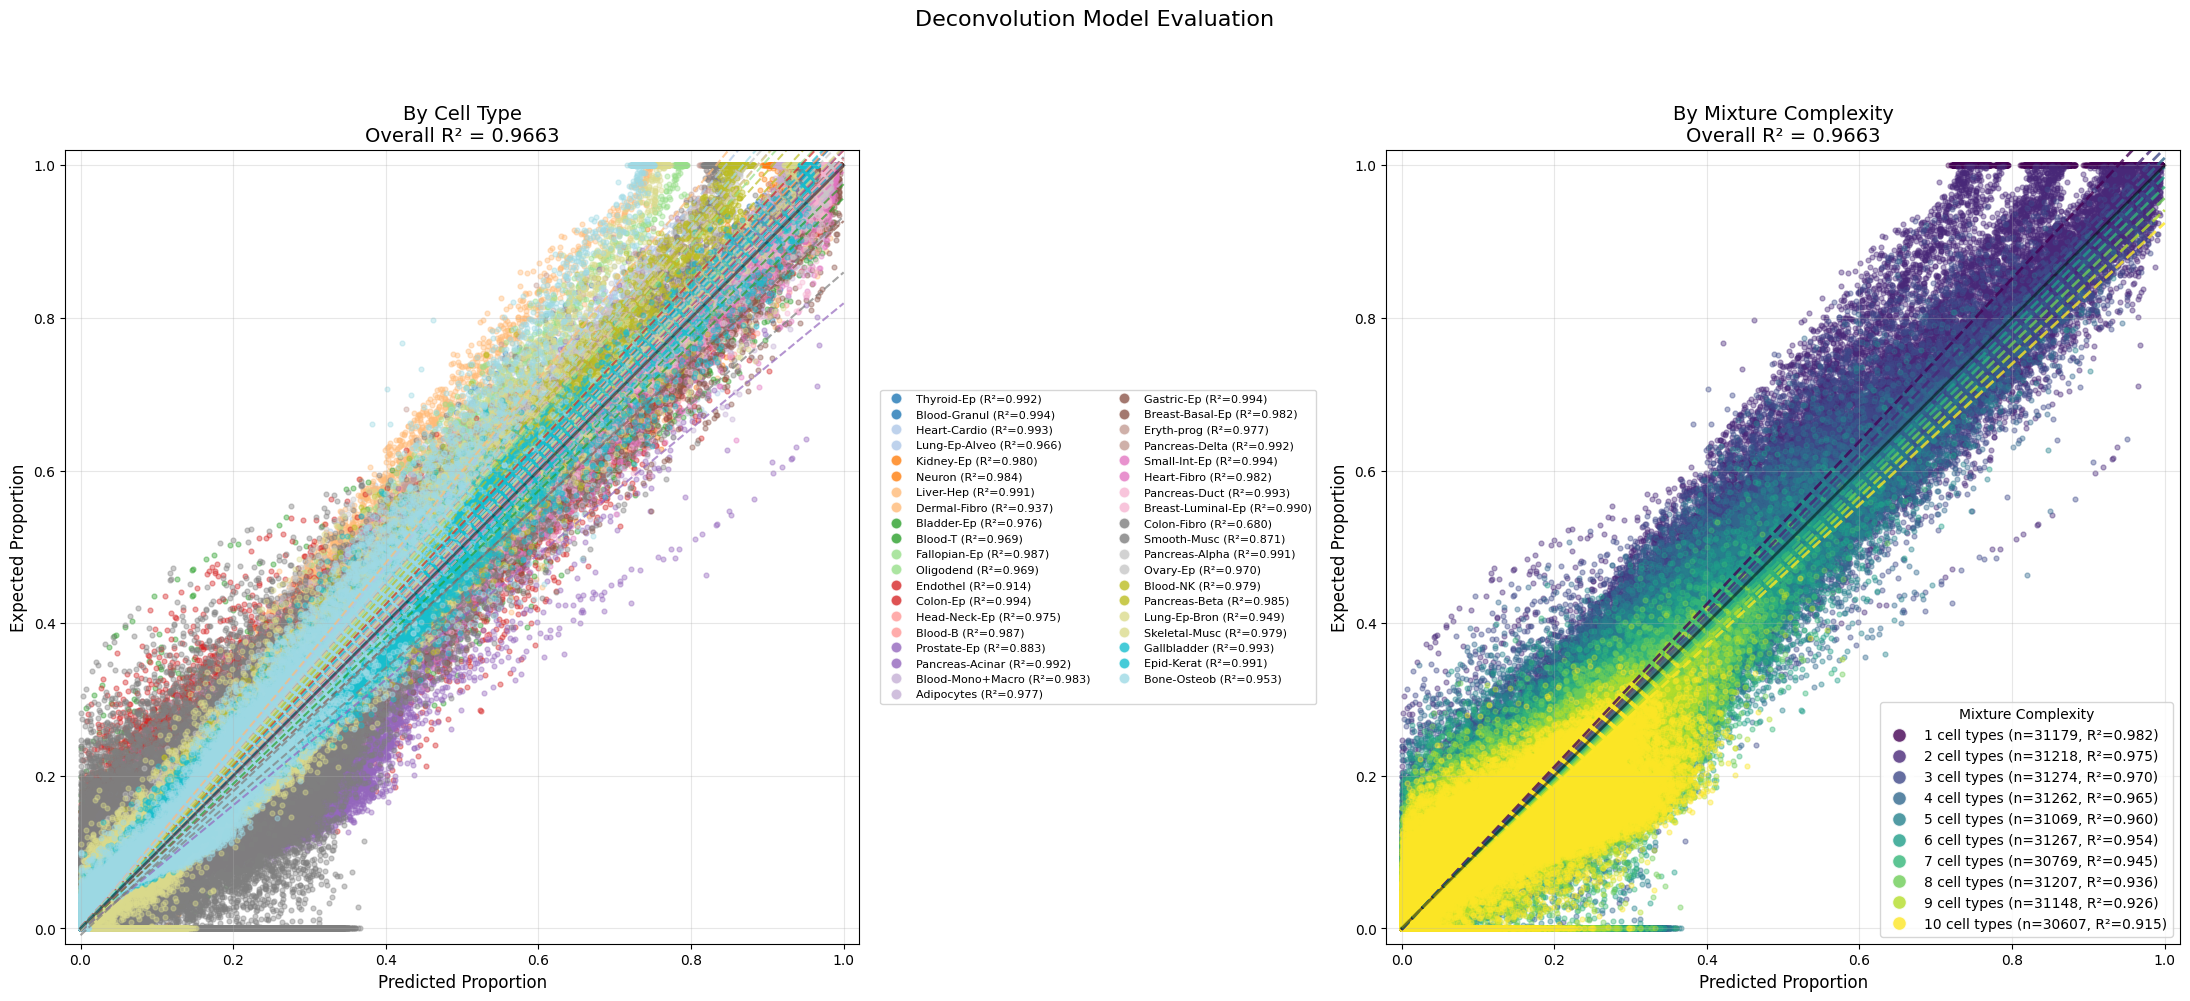

In [404]:
if mode == "training":
    histories = defaultdict(list)
    for model, model_name in model_pairs:

        # Train with early stopping on MAE
        model, history = train_matrix_deconvolver(
            model=model,
            X_train=train_features,
            y_train=train_outputs,
            X_val=valid_features,
            y_val=valid_outputs,
            n_epochs=5000,
            batch_size=500,
            lr=0.5 * 1e-4,
            weight_decay=1e-3,
            device="cuda",
            early_stopping_metric=early_stopping_metric,  # or 'val_loss', 'val_cosine_sim', etc.
            early_stopping_patience=3000,  # n_epochs == patience --> no early stopping
            early_stopping_min_delta=1e-5,
            scheduler_type=None,
            loss_weights={"mse": 1.0, "kl": 0.5},
            verbose=1,
            save_path=f"deconvolution_models/{model_name}_best_deconvolver.pt",
        )
        histories[model_name] = history
        # Access history
        print(f"Stopped early: {history.stopped_early}")
        print(f"Best epoch: {history.best_epoch + 1}")
        print(f"Final val MAE: {history.val_mae[history.best_epoch]:.4f}")
elif mode == "inference":
    device = "cuda"
    test_loader = DataLoader(
        TensorDataset(
            torch.FloatTensor(test_features), torch.FloatTensor(test_outputs)
        ),
        batch_size=2000,
    )
    results = defaultdict(tuple)
    for model, model_name in model_pairs:
        model.to(device)
        model.load_state_dict(
            torch.load(
                f"deconvolution_models/{model_name}_best_deconvolver.pt",
                weights_only=True,
            )
        )
        model.eval()

        all_preds = []
        all_targets = []

        with torch.no_grad():
            for X, y in test_loader:
                X, y = X.to(device), y.to(device)
                pred = model(X)

                all_preds.append(pred.cpu())
                all_targets.append(y.cpu())

        # Compute all metrics
        all_preds = torch.cat(all_preds, dim=0)
        all_targets = torch.cat(all_targets, dim=0)
        metrics = compute_deconvolution_metrics(all_preds, all_targets)
        all_targets = all_targets.numpy()
        all_preds = np.round(all_preds.numpy(), 4)

        results[model_name] = (all_targets, all_preds, metrics)
        try:
            fig, all_metrics = plot_deconvolution_results(
                y_true=all_targets,
                y_pred=all_preds,
                labels_dict=labels_dict,
                figsize=(22, 10),
                zero_threshold=0.0001,
                save_path=f"plots/{model_name}_loyfer_test_resuts.png",
                alpha=0.4,
                point_size=12,
            )
        except:
            pass

In [ ]:
# all_preds = xgb_model._predict_raw(test_features)
# all_preds = xgb_model._transform_output(test_features)

In [ ]:
all_targets = train_outputs
all_preds = np.array(xgb_model.predict(test_features))

DECONVOLUTION RESULTS SUMMARY

📊 Overall R²: 0.9417

📋 Per Cell Type R²:
----------------------------------------
  Liver-Hep            │ ███████████████████░ │ 0.9945
  Blood-Granul         │ ███████████████████░ │ 0.9940
  Breast-Basal-Ep      │ ███████████████████░ │ 0.9912
  Small-Int-Ep         │ ███████████████████░ │ 0.9884
  Gastric-Ep           │ ███████████████████░ │ 0.9863
  Breast-Luminal-Ep    │ ███████████████████░ │ 0.9845
  Heart-Cardio         │ ███████████████████░ │ 0.9842
  Colon-Ep             │ ███████████████████░ │ 0.9814
  Thyroid-Ep           │ ███████████████████░ │ 0.9808
  Neuron               │ ███████████████████░ │ 0.9772
  Pancreas-Alpha       │ ███████████████████░ │ 0.9767
  Pancreas-Duct        │ ███████████████████░ │ 0.9736
  Pancreas-Delta       │ ███████████████████░ │ 0.9690
  Blood-Mono+Macro     │ ███████████████████░ │ 0.9633
  Oligodend            │ ███████████████████░ │ 0.9595
  Blood-B              │ ███████████████████░ │ 0.9580
  Fall

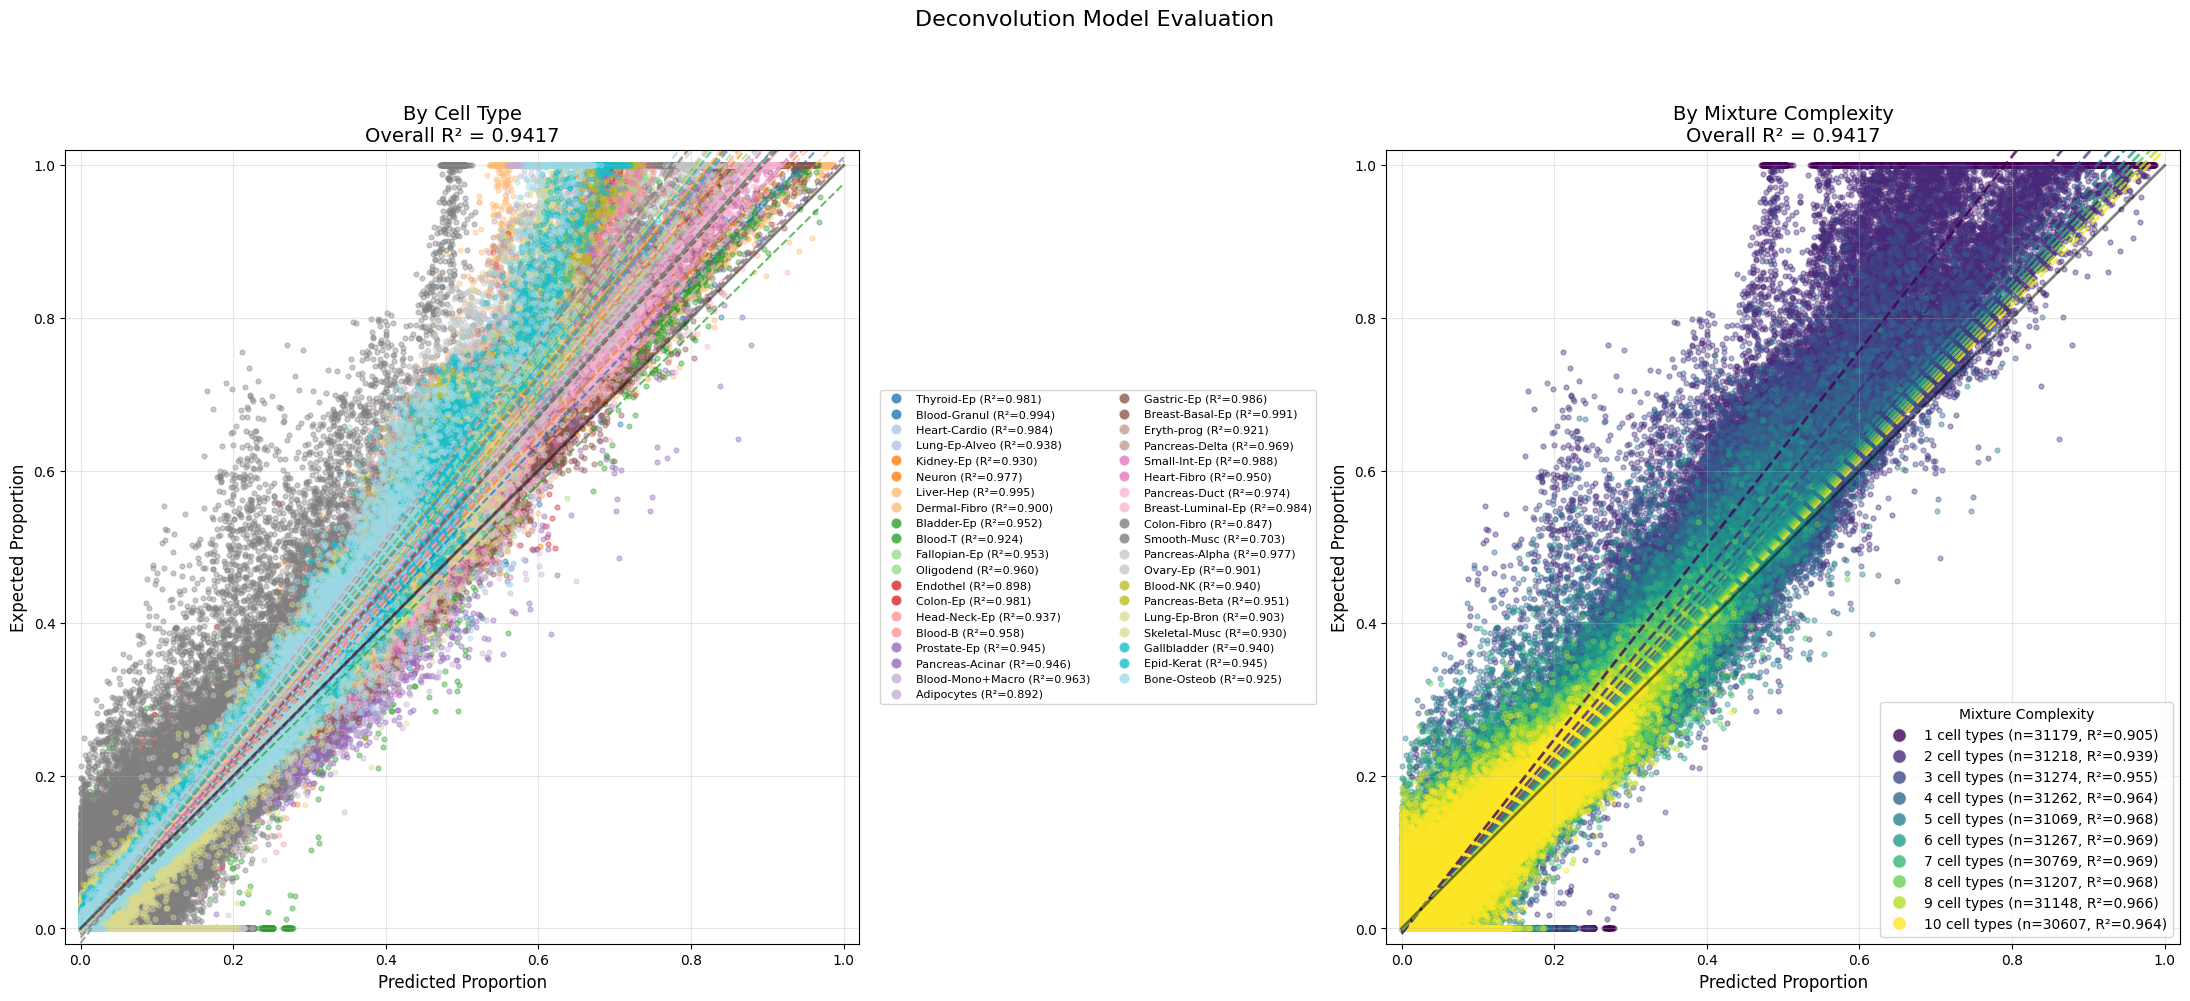

In [80]:
fig, all_metrics = plot_deconvolution_results(
    y_true=all_targets,
    y_pred=all_preds,
    labels_dict=labels_dict,
    figsize=(22, 10),
    zero_threshold=0.0001,
    save_path="deconvolution_results.png",
    alpha=0.4,
    point_size=12,
)

# Print summary
print_deconvolution_metrics_summary(all_metrics)

In [9]:
with open("crc_ont_parsed_with_uxm_results", "rb") as f:
    results, uxm_res_dict = pickle.load(f)

In [10]:
from methyldl.modelling.methylbert import MethylVocab, MethylBertFinetuneDataset
from methyldl.data.genome import generate_kmer_str_with_overlap
from methyldl.data import CELL_TYPE_MATCH_DICT as cell_type_match_dict
from methyldl.modelling.methylbert import MethylBert, default_methylbert_config

/home/luna.kuleuven.be/u0169940/.cache/pypoetry/virtualenvs/methyldl-GStZGe-R-py3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
dmr_label_column = "dmr_ctype_label"
seq_length = 150
dmrs = pd.DataFrame(
    pd.concat(
        [
            pd.read_parquet(reads_data_path + f"/{split}.parquet")
            for split in ["train", "valid", "test"]
        ]
    )[dmr_label_column].unique()
)
dmrs.columns = [dmr_label_column]

In [12]:
from collections import OrderedDict

rrms_config = OrderedDict(
    [
        ("lr", 0.0004),
        ("beta", (0.9, 0.98)),
        ("weight_decay", 0.1),
        ("warmup_step", 100),
        ("eps", 1e-6),
        ("with_cuda", True),
        ("log_freq", 200),
        ("eval_freq", 200),
        ("n_hidden", None),
        ("decrease_steps", 200),
        ("eval", False),
        ("amp", True),
        ("gradient_accumulation_steps", 1),
        ("max_grad_norm", 1.0),
        ("save_freq", None),
        ("loss", "ce"),
        ("adam_beta1", 0.9),
        ("adam_beta2", 0.98),
        ("seed", 950410),
    ]
)

model_instance = MethylBert(
    custom_config=rrms_config,
    foundation_model_path="hanyangii/methylbert_hg19_12l",
    num_labels=40,
    num_dmr_labels=max(dmrs[dmr_label_column]) + 1,
    fine_tuned_model_path=fine_tuned_model_path,
    classifier_implementation="dmr_attention_based",
)

Loading MethylBertEmbeddedDMR with dmr_attention_based classifier from fine-tuned path: ../Tutorials/methylBertLoyferWithReject_attentionClassifier_DMRs_stratified_hg38_dmr_ctype_label_mincpg_4_minlen_10/checkpoint-1650/model.safetensors
Cross Entropy loss assigned (multi-class)
Using attention-based classifier with DMR context


In [13]:
def generate_valid_tokens(read_data, k=3):
    """
    Yields valid k-mers and their ORIGINAL indices.
    Skips any k-mer containing 'N'.
    """
    seq = read_data["input_ids"]
    pattern = read_data["methylation_ids"]

    # We iterate up to len(seq) - k + 1
    for i in range(len(seq) - k + 1):
        kmer = seq[i : i + k]

        # 1. Check for 'N' in the window
        if "N" in kmer:
            continue

        center_idx = i + 1
        methylation_code = pattern[center_idx]

        # Yield the clean k-mer and its specific methylation label
        yield [kmer, methylation_code]

In [14]:
def chunk_tokens(tokens, window_size, stride):
    """
    Splits a list of tokens into overlapping chunks of fixed size.
    Ensures no chunk is shorter than window_size (unless the total read is shorter).
    """
    total_len = len(tokens)

    # Case 1: Read is shorter than the window. Return as is.
    if total_len <= window_size:
        yield tokens
        return

    # Case 2: Sliding window
    # We iterate until the window would go out of bounds
    for i in range(0, total_len - window_size + 1, stride):
        yield tokens[i : i + window_size]

    # Case 3: Handle the "Tail"
    # If the last sliding window didn't exactly align with the end,
    # we yield one final chunk containing the *last* window_size elements.
    # This creates a variable overlap for the last segment, but ensures full context.
    if total_len % stride != 0:
        yield tokens[-window_size:]


def prepare_methylbert_list_inference(
    results_df, dmr_label_column, seq_length=150, stride=75
):
    """
    Prepares inference data with sliding window chunking.
    params:
        stride: How far to move the window (75 = 50% overlap for 150bp window)
    """
    data_list = [
        [
            "dna_seq",
            "methyl_seq",
            "dmr_ctype",
            "dmr_label",
            "ctype",
            "original_label",
            "read_name",
            "ncpgs_marked",
        ]
    ]

    for i, row in results_df.iterrows():
        # 1. Get the CLEAN stream of tokens (Ns removed)
        processed_read_full = list(generate_valid_tokens(row))
        read_name = row["read_name"]
        # If read was entirely Ns or empty, skip
        if not processed_read_full:
            continue

        # 2. Chunk the valid tokens
        # We process the read in chunks of 'seq_length'
        for chunk in chunk_tokens(
            processed_read_full, window_size=seq_length, stride=stride
        ):

            dna = " ".join([x[0] for x in chunk])
            methyl = "".join([x[1] for x in chunk])
            ncpgs_marked = methyl.count("0") + methyl.count("1")
            # Metadata propagation
            # Note: You might want to track which chunk this is (e.g., read_id_0, read_id_1)
            # but for bulk inference, this format works.
            label = 39
            o_label = 39
            dmr_label = row[dmr_label_column]
            dmr_ctype = row["dmr_ctype_label"]

            data_list.append(
                [
                    dna,
                    methyl,
                    dmr_ctype,
                    dmr_label,
                    label,
                    o_label,
                    read_name,
                    ncpgs_marked,
                ]
            )

    return data_list

In [ ]:
results.rename(columns={"seq": "input_ids", "pattern": "methylation_ids"}, inplace=True)
results_for_methylbert = results[results["pattern_len"] >= 3]
out_of_bag_test = prepare_methylbert_list_inference(
    results_for_methylbert, dmr_label_column=dmr_label_column, seq_length=seq_length
)

In [16]:
out_of_bag_dataset = MethylBertFinetuneDataset(
    data_source=out_of_bag_test,
    vocab=MethylVocab(k=3),
    seq_len=seq_length,
    lazy_tokenization=True,
)
out_of_bag_predicitons = model_instance.predict(out_of_bag_dataset, batch_size=2200)
out_of_bag_predicitons_pd = pd.DataFrame(
    out_of_bag_predicitons[0], columns=["prediction_" + str(x) for x in range(40)]
)
# results_for_methylbert = pd.concat([results_for_methylbert.reset_index(), out_of_bag_predicitons_pd.reset_index()],axis=1)
# results_for_methylbert.rename(columns={"methylated_cpgs":"methylated_CpGs",
#                            "unmethylated_cpgs":"unmethylated_CpGs",
#                            "methylation_rate":"methylation_level"}, inplace=True)

Building Vocab
Total number of sequences: 145695
Using lazy tokenization (on-the-fly processing)
OUTPUT DIR IS: tmp_trainer


/home/luna.kuleuven.be/u0169940/Repos/methyldl/methyldl/modelling/methylbert.py:581: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.
You may ignore this warning if your `pad_token_id` (0) is identical to the `bos_token_id` (0), `eos_token_id` (None), or the `sep_token_id` (None), and your input is not padded.


In [17]:
out_of_bag_predicitons_pd["read_name"] = [x[-2] for x in out_of_bag_test[1:]]
out_of_bag_predicitons_pd["ncpgs_marked"] = [x[-1] for x in out_of_bag_test[1:]]

In [18]:
def aggregate_predictions_weighted(
    pred_df, weight_col="ncpgs_marked", group_col="read_name"
):
    """
    Calculates the weighted average of prediction columns grouped by read_name.
    """
    # 1. Identify prediction columns (prediction_0 ... prediction_39)
    pred_cols = [c for c in pred_df.columns if c.startswith("prediction_")]

    # 2. Create a working copy to avoid SettingWithCopy warnings
    df = pred_df.copy()

    # 3. Vectorized Weighting: Multiply all prediction columns by the weight column
    # This is much faster than doing it inside the groupby
    df[pred_cols] = df[pred_cols].multiply(df[weight_col], axis=0)

    # 4. Group by read_name and sum both the weighted predictions and the weights
    grouped = df.groupby(group_col)

    # Sum the weighted scores
    summed_preds = grouped[pred_cols].sum()

    # Sum the weights (the total number of CpGs seen across all chunks for this read)
    summed_weights = grouped[weight_col].sum()

    # 5. Divide to get the Weighted Average
    # We use .div with axis=0 to align by the index (read_name)
    final_averaged_df = summed_preds.div(summed_weights, axis=0)

    # 6. Cleanup
    # Handle cases where total weight might be 0 (avoid division by zero errors)
    # Though your filtering likely prevents this, it's good practice.
    final_averaged_df = final_averaged_df.fillna(0)

    # Reset index so 'read_name' becomes a column again
    return final_averaged_df.reset_index()

In [19]:
out_of_bag_predicitons_pd = aggregate_predictions_weighted(out_of_bag_predicitons_pd)

In [20]:
results_for_methylbert = pd.merge(
    results_for_methylbert, out_of_bag_predicitons_pd, on="read_name"
).dropna()

In [ ]:
# with open(f"{classifier_model_path}/crc_results.pkl", "wb") as f:
#     pickle.dump(results_for_methylbert,f)

In [ ]:
# with open(f"{classifier_model_path}/bsbolt_wgbs_results_v2.pkl", "rb") as f:
#     results_for_methylbert = pickle.load(f)

In [22]:
results_for_methylbert.dropna(inplace=True)
results_for_methylbert.rename(columns={"M_rate": "methylation_level"}, inplace=True)

In [23]:
def sample_bulk(total_samples, data):
    res = defaultdict(lambda: pd.DataFrame)
    grouped = data.groupby(["file", "dmr_ctype_label"], sort=False)
    for file in [str(x) for x in data["file"].unique()]:
        sub = []
        for dmr_ctype_label in range(39):
            try:
                group = grouped.get_group((file, dmr_ctype_label))
            except:
                print(
                    f"{(file,dmr_ctype_label)} is absent from the data and will be not included into samples"
                )
            sub.append(group.sample(int(total_samples / 39), replace=True))
        sub = pd.concat(sub)
        # sub = data[data["file"]==file]
        res[file] = aggregate_predictions_by_dmr(
            sub, group_cols=["dmr_ctype_label", "dmr_ctype"], weight_col="NCPGS"
        )
    return res

In [24]:
out_of_bag_deconv_inputs = sample_bulk(
    300_000,
    results_for_methylbert[
        (results_for_methylbert["NCPGS"] >= 4)
        & (results_for_methylbert["pattern_len"] >= 0)
    ],
)

In [25]:
labels_reversed_pd = pd.DataFrame(labels_dict_reversed, index=[0]).T.reset_index()
labels_reversed_pd.columns = ["dmr_ctype", "dmr_ctype_label"]

In [29]:
xgb_model = XGBoostDeconvolver()
xgb_model = xgb_model.load("deconvolution_models/xgb_dpth15.pt")

In [30]:
xgb_model.process_inputs = True
deconv_results = defaultdict(lambda: defaultdict(np.array))
for key in out_of_bag_deconv_inputs.keys():
    X = np.array(
        out_of_bag_deconv_inputs[key][[f"prediction_{i}_wavg" for i in range(40)]]
    )

    X = xgb_model.extract_features(X)
    deconv_preds = xgb_model._predict_raw(X)
    deconv_preds = xgb_model._transform_output(deconv_preds)[0]

    # deconv_preds = xgb_model.predict(X)

    deconv_preds = np.round(deconv_preds, 4)
    deconv_results["XGB"][key] = deconv_preds

In [43]:
mlp_deep = nn.Sequential(
    nn.Linear(78, 128),
    nn.GELU(),
    nn.Dropout(0.2),
    nn.Linear(128, 128),
    nn.GELU(),
    nn.Dropout(0.2),
    nn.Linear(128, 64),
    nn.GELU(),
    nn.Dropout(0.2),
    nn.Linear(64, 39),
    nn.GELU(),
    nn.Softmax(dim=-1),
)

In [44]:
os.path.join(classifier_model_path, "3LMLP_best_deconvolver.pt")

'../Tutorials/methylBertLoyferWithReject_attentionClassifier_DMRs_stratified_hg38_dmr_ctype_label_mincpg_4_minlen_10/3LMLP_best_deconvolver.pt'

In [48]:
device = "cuda"
model_name = "mlp3l"
model = mlp_deep
model.to(device)
model.load_state_dict(
    torch.load(
        os.path.join(classifier_model_path, "3LMLP_best_deconvolver.pt"),
        weights_only=True,
    )
)
model.eval()

Sequential(
  (0): Linear(in_features=78, out_features=128, bias=True)
  (1): GELU(approximate='none')
  (2): Dropout(p=0.2, inplace=False)
  (3): Linear(in_features=128, out_features=128, bias=True)
  (4): GELU(approximate='none')
  (5): Dropout(p=0.2, inplace=False)
  (6): Linear(in_features=128, out_features=64, bias=True)
  (7): GELU(approximate='none')
  (8): Dropout(p=0.2, inplace=False)
  (9): Linear(in_features=64, out_features=39, bias=True)
  (10): GELU(approximate='none')
  (11): Softmax(dim=-1)
)

In [ ]:
# model_name = "mlp"
# model = mlp_deep
# model.to(device)
# model.load_state_dict(torch.load(f"deconvolution_models/{model_name}_best_deconvolver.pt", weights_only=True))
# model.eval()

Sequential(
  (0): Linear(in_features=78, out_features=1024, bias=True)
  (1): GELU(approximate='none')
  (2): Dropout(p=0.2, inplace=False)
  (3): Linear(in_features=1024, out_features=39, bias=True)
  (4): Softmax(dim=-1)
)

In [74]:
device = "cuda"
# deconv_results = defaultdict(lambda: defaultdict(np.array))
for key in out_of_bag_deconv_inputs.keys():
    X = torch.FloatTensor(
        np.array(
            out_of_bag_deconv_inputs[key][[f"prediction_{i}_wavg" for i in range(40)]]
        )
    ).to("cuda")
    X = torch.unsqueeze(X, 0)
    X = torch.concat([torch.diagonal(X[:, :, :39], dim1=1, dim2=2), X[:, :, -1]], dim=1)
    for model, model_name in zip([mlp_deep], ["mlp3l"]):
        model.to(device)
        # model.load_state_dict(torch.load(f"deconvolution_models/{model_name}_best_deconvolver.pt", weights_only=True))
        model.eval()
        deconv_preds = model(X)
        deconv_preds = np.round(deconv_preds.to("cpu").detach().numpy(), 4)
        deconv_results[model_name][key] = deconv_preds[0]

In [64]:
eps = 1e-8
for key in deconv_results["mlp3l"].keys():
    deconv_preds = np.array(deconv_results["mlp3l"][key])
    uxm_preds = deepcopy(uxm_res_dict[key])
    uxm_preds = np.array([uxm_preds[key] for key in labels_dict.values()])

    target_safe = np.clip(uxm_preds, eps, None)
    pred_safe = np.clip(deconv_preds, eps, None)
    kl = (target_safe * (np.log(target_safe) - np.log(pred_safe))).sum(axis=-1).mean()
    print(kl)

8.71362605529592


In [75]:
for model_name in ["mlp3l"]:
    # if model =="diagd":
    print(f"Model: {model_name}")
    print("_" * 80)
    print("_" * 80)
    for key in deconv_results["mlp3l"].keys():
        deconv_preds = deconv_results[model_name][key]
        uxm_preds = uxm_res_dict[key]
        uxm_preds = np.array([uxm_preds[key] for key in labels_dict.values()])
        print(key)
        for i in np.where(np.round(uxm_preds, 2) > 0.025)[0]:
            print(f"{labels_dict[int(i)]}: {deconv_preds[i]:.2f} vs {uxm_preds[i]:.2f}")
        print("_" * 80)
        print("\n")

Model: mlp3l
________________________________________________________________________________
________________________________________________________________________________
/data/dmytro/20251216_1438_P2S-01099-A_PBE88013_e323d012/20251216_1438_P2S-01099-A_PBE88013_e323d012/basecalling/CRC001_N01/CRC001_N01.meth_atlas25.bam
Kidney-Ep: 0.00 vs 0.03
Neuron: 0.00 vs 0.05
Bladder-Ep: 0.00 vs 0.03
Blood-T: 0.00 vs 0.03
Colon-Ep: 0.89 vs 0.20
Blood-Mono+Macro: 0.00 vs 0.04
Small-Int-Ep: 0.00 vs 0.04
Pancreas-Duct: 0.00 vs 0.03
Colon-Fibro: 0.00 vs 0.06
Pancreas-Beta: 0.00 vs 0.03
Skeletal-Musc: 0.00 vs 0.03
Gallbladder: 0.00 vs 0.03
________________________________________________________________________________




#### Test BSBolt UXM proportions mixes from Loyfer Reference Data ####

In [52]:
import sys

repo_path = os.path.abspath("../../UXM_deconv/src")
if repo_path not in sys.path:
    sys.path.append(repo_path)
from src.deconv import load_atlas, decon_single_samp

atlas_location = "../../UXM_deconv/supplemental/Atlas.U25.l4.hg38.full.tsv"
atlas, ref_cells = load_atlas(atlas_location)
atlas = atlas.sort_values(by=["chr", "start", "end"], ascending=True).reset_index(
    drop=True
)

In [53]:
ref_cells = [x for x in ref_cells if x != "Megakaryocytes"]

In [35]:
labels = list(range(39))
proportions = uxm_preds / sum(uxm_preds)

In [36]:
xgb_bsbolt_results = deepcopy(deconv_results)

In [37]:
pd.set_option("future.no_silent_downcasting", True)

In [38]:
import warnings

warnings.filterwarnings("ignore")

In [39]:
eps = 1e-8
splits = ["train", "valid", "test"]
deconv_results = defaultdict(lambda: defaultdict(np.array))
uxm_deconv_results = defaultdict(lambda: defaultdict(np.array))
sim_features_dict = defaultdict(lambda: pd.DataFrame)
for key in uxm_res_dict.keys():
    key = str(key)
    uxm_preds = deepcopy(uxm_res_dict[key])
    uxm_preds = np.array([uxm_preds[key] for key in labels_dict.values()])
    xgb_preds = deepcopy(xgb_bsbolt_results["XGB"][key])
    target_safe = np.clip(uxm_preds, eps, None)
    xgb_pred_safe = np.clip(xgb_preds, eps, None)
    kl = (
        (target_safe * (np.log(target_safe) - np.log(xgb_pred_safe)))
        .sum(axis=-1)
        .mean()
    )
    labels = list(range(39))
    proportions = uxm_preds / sum(uxm_preds)
    print(key, f"UXM-XGB KL: {round(kl,4)}")
    n_read_per_split = 300_000
    _, proportions, subs, uxm_data = generate_pseudo_bulk(
        n_read_per_split,
        labels,
        proportions,
        train_split_uxm_input,
        valid_split_uxm_input,
        test_split_uxm_input,
        atlas,
        ref_cells,
        labels_dict_reversed,
    )
    if mincpg != 4:
        ### We need to regenerate uxm inputs for such scenario
        _, _, _, uxm_data = generate_pseudo_bulk(
            n_read_per_split,
            labels,
            proportions,
            train_split_uxm_input[train_split_uxm_input["NCPGS"] > 3],
            valid_split_uxm_input[valid_split_uxm_input["NCPGS"] > 3],
            test_split_uxm_input[test_split_uxm_input["NCPGS"] > 3],
            atlas,
            ref_cells,
            labels_dict_reversed,
        )
    sim_features_dict[key] = subs
    for row in range(3):
        X = np.array(subs[row][[f"prediction_{i}_wavg" for i in range(40)]])
        X = xgb_model.extract_features(X)
        deconv_preds = xgb_model._predict_raw(X)
        deconv_preds = xgb_model._transform_output(deconv_preds)[0]

        # deconv_preds = xgb_model.predict(X)

        deconv_preds = np.round(deconv_preds, 4)
        target_safe = np.clip(uxm_preds, eps, None)
        pred_safe = np.clip(deconv_preds, eps, None)
        sf = uxm_data[row][0]
        counts = uxm_data[row][1]
        uxm_proportions = uxm_deconvolution(
            atlas, ref_cells, sf, counts, sample_names=["pseudo_balk_sample"]
        )[0]
        uxm_deconv = {x: np.round(y, 4) for (x, y) in zip(ref_cells, uxm_proportions)}
        uxm_deconv_alligned = rearange_uxm_deconvolution_results(
            labels_dict_reversed, uxm_proportions, ref_cells
        )
        uxm_deconv_alligned_safe = np.clip(uxm_deconv_alligned, eps, None)
        kl_uxm_xgb = (
            (target_safe * (np.log(target_safe) - np.log(pred_safe)))
            .sum(axis=-1)
            .mean()
        )
        kl_uxm_uxm = (
            (target_safe * (np.log(target_safe) - np.log(uxm_deconv_alligned_safe)))
            .sum(axis=-1)
            .mean()
        )
        kl_xgb_xgb = (
            (xgb_pred_safe * (np.log(xgb_pred_safe) - np.log(pred_safe)))
            .sum(axis=-1)
            .mean()
        )
        kl_uxmsim_xgbsim = (
            (
                uxm_deconv_alligned_safe
                * (np.log(uxm_deconv_alligned_safe) - np.log(pred_safe))
            )
            .sum(axis=-1)
            .mean()
        )
        print(
            f"{splits[row]} UXM-XGB(sim) KL:",
            round(kl_uxm_xgb, 4),
            "------",
            "UXM-UXM(sim) KL:",
            round(kl_uxm_uxm, 4),
            "------",
            "XGB-XGB(sim) KL:",
            round(kl_xgb_xgb, 4),
            "------",
            "UXM(sim)-XGB(sim) KL:",
            round(kl_uxmsim_xgbsim, 4),
        )
        deconv_results[key][row] = deconv_preds
        uxm_deconv_results[key][row] = uxm_deconv_alligned

/data/dmytro/20251216_1438_P2S-01099-A_PBE88013_e323d012/20251216_1438_P2S-01099-A_PBE88013_e323d012/basecalling/CRC001_N01/CRC001_N01.meth_atlas25.bam UXM-XGB KL: 0.7487
train UXM-XGB(sim) KL: 1.4943 ------ UXM-UXM(sim) KL: 0.0209 ------ XGB-XGB(sim) KL: 2.0545 ------ UXM(sim)-XGB(sim) KL: 1.5311
valid UXM-XGB(sim) KL: 1.8451 ------ UXM-UXM(sim) KL: 0.0273 ------ XGB-XGB(sim) KL: 2.1677 ------ UXM(sim)-XGB(sim) KL: 1.649
test UXM-XGB(sim) KL: 1.3146 ------ UXM-UXM(sim) KL: 0.0878 ------ XGB-XGB(sim) KL: 2.1605 ------ UXM(sim)-XGB(sim) KL: 1.2309


In [76]:
ourmodel_bsbolt_results = deepcopy(deconv_results)
ourmodel_model = mlp_deep

In [77]:
modle_name = "3LMLP"
eps = 1e-8
splits = ["train", "valid", "test"]
deconv_results = defaultdict(lambda: defaultdict(np.array))
uxm_deconv_results = defaultdict(lambda: defaultdict(np.array))
sim_features_dict = defaultdict(lambda: pd.DataFrame)
for key in uxm_res_dict.keys():
    key = str(key)
    uxm_preds = deepcopy(uxm_res_dict[key])
    uxm_preds = np.array([uxm_preds[key] for key in labels_dict.values()])
    ourmodel_preds = deepcopy(ourmodel_bsbolt_results["mlp3l"][key])
    target_safe = np.clip(uxm_preds, eps, None)
    ourmodel_pred_safe = np.clip(ourmodel_preds, eps, None)
    kl = (
        (target_safe * (np.log(target_safe) - np.log(ourmodel_pred_safe)))
        .sum(axis=-1)
        .mean()
    )
    labels = list(range(39))
    proportions = uxm_preds / sum(uxm_preds)
    print(key, f"UXM-{modle_name} KL: {round(kl,4)}")
    n_read_per_split = 300_000
    _, proportions, subs, uxm_data = generate_pseudo_bulk(
        n_read_per_split,
        labels,
        proportions,
        train_split_uxm_input,
        valid_split_uxm_input,
        test_split_uxm_input,
        atlas,
        ref_cells,
        labels_dict_reversed,
    )
    if mincpg != 4:
        ### We need to regenerate uxm inputs for such scenario
        _, _, _, uxm_data = generate_pseudo_bulk(
            n_read_per_split,
            labels,
            proportions,
            train_split_uxm_input[train_split_uxm_input["NCPGS"] > 3],
            valid_split_uxm_input[valid_split_uxm_input["NCPGS"] > 3],
            test_split_uxm_input[test_split_uxm_input["NCPGS"] > 3],
            atlas,
            ref_cells,
            labels_dict_reversed,
        )
    sim_features_dict[key] = subs
    for row in range(3):
        X = torch.FloatTensor(
            np.array(subs[row][[f"prediction_{i}_wavg" for i in range(40)]])
        ).to("cuda")
        X = torch.unsqueeze(X, 0)
        X = torch.concat(
            [torch.diagonal(X[:, :, :39], dim1=1, dim2=2), X[:, :, -1]], dim=1
        )
        deconv_preds = model(X)
        deconv_preds = np.round(deconv_preds.to("cpu").detach().numpy(), 4)
        target_safe = np.clip(uxm_preds, eps, None)
        pred_safe = np.clip(deconv_preds, eps, None)
        sf = uxm_data[row][0]
        counts = uxm_data[row][1]
        uxm_proportions = uxm_deconvolution(
            atlas, ref_cells, sf, counts, sample_names=["pseudo_balk_sample"]
        )[0]
        uxm_deconv = {x: np.round(y, 4) for (x, y) in zip(ref_cells, uxm_proportions)}
        uxm_deconv_alligned = rearange_uxm_deconvolution_results(
            labels_dict_reversed, uxm_proportions, ref_cells
        )
        uxm_deconv_alligned_safe = np.clip(uxm_deconv_alligned, eps, None)
        kl_uxm_diagd = (
            (target_safe * (np.log(target_safe) - np.log(pred_safe)))
            .sum(axis=-1)
            .mean()
        )
        kl_uxm_uxm = (
            (target_safe * (np.log(target_safe) - np.log(uxm_deconv_alligned_safe)))
            .sum(axis=-1)
            .mean()
        )
        kl_ourmodel_diagd = (
            (ourmodel_pred_safe * (np.log(ourmodel_pred_safe) - np.log(pred_safe)))
            .sum(axis=-1)
            .mean()
        )

        kl_uxmsim_diagdsim = (
            (
                uxm_deconv_alligned_safe
                * (np.log(uxm_deconv_alligned_safe) - np.log(pred_safe))
            )
            .sum(axis=-1)
            .mean()
        )
        print(
            f"{splits[row]} UXM-{modle_name}(sim) KL:",
            round(kl_uxm_diagd, 4),
            "------",
            "UXM-UXM(sim) KL:",
            round(kl_uxm_uxm, 4),
            "------",
            f"{modle_name}-{modle_name}(sim) KL:",
            round(kl_ourmodel_diagd, 4),
            "------",
            f"UXM(sim)-{modle_name}(sim) KL:",
            round(kl_uxmsim_diagdsim, 4),
        )
        deconv_results[key][row] = deconv_preds[0]
        uxm_deconv_results[key][row] = uxm_deconv_alligned

/data/dmytro/20251216_1438_P2S-01099-A_PBE88013_e323d012/20251216_1438_P2S-01099-A_PBE88013_e323d012/basecalling/CRC001_N01/CRC001_N01.meth_atlas25.bam UXM-3LMLP KL: 8.7136
train UXM-3LMLP(sim) KL: 0.1414 ------ UXM-UXM(sim) KL: 0.0884 ------ 3LMLP-3LMLP(sim) KL: 2.1566 ------ UXM(sim)-3LMLP(sim) KL: 0.146
valid UXM-3LMLP(sim) KL: 0.1421 ------ UXM-UXM(sim) KL: 0.0455 ------ 3LMLP-3LMLP(sim) KL: 2.1543 ------ UXM(sim)-3LMLP(sim) KL: 0.1802
test UXM-3LMLP(sim) KL: 0.1662 ------ UXM-UXM(sim) KL: 0.0293 ------ 3LMLP-3LMLP(sim) KL: 2.1709 ------ UXM(sim)-3LMLP(sim) KL: 0.1572


In [78]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from pathlib import Path


def plot_all_samples_stacked(
    sample_keys: list,
    labels_dict: dict,
    labels_dict_reversed: dict,
    uxm_res_dict: dict,
    our_model_bsbolt_results: dict,
    uxm_sim_results: dict,
    model_key: str,
    our_model_sim_results: dict,
    output_dir: str = "celltype_dumbbells",
    figsize: tuple = (40, 14),  # Very wide figure for 4 stacked plots
    top_n: int = None,
):
    """
    Creates a vertically stacked grid of dumbbell plots for all provided samples.
    The y-axis sorting is determined globally (average across ALL samples).
    """

    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)

    # ---------------------------------------------------------
    # 1. Determine GLOBAL Sorting Order (Average across ALL samples)
    # ---------------------------------------------------------
    # Initialize sums for all cell types found in labels_dict
    cell_sums = {k: 0.0 for k in labels_dict.values()}
    cell_counts = {k: 0 for k in labels_dict.values()}

    # Iterate over ALL samples available in uxm_res_dict to build global average
    for s_key, res in uxm_res_dict.items():
        for cell_name, prop in res.items():
            # Check if this cell is in our target list
            if cell_name in labels_dict_reversed:
                # Note: labels_dict_reversed maps index -> name,
                # but cell_sums is keyed by Name (from labels_dict.values())
                # OR keyed by whatever labels_dict.values() returns.
                # Let's stick to using the NAMES as keys for safety and clarity.
                pass

            # Simplified Logic: Accumulate by Name
            if cell_name in cell_sums:
                cell_sums[cell_name] += prop
                cell_counts[cell_name] += 1
            elif (
                cell_name in labels_dict
            ):  # If res has names not in values but in keys?
                # Assuming uxm_res_dict keys are cell NAMES
                cell_sums[cell_name] = cell_sums.get(cell_name, 0) + prop
                cell_counts[cell_name] = cell_counts.get(cell_name, 0) + 1

    # Calculate averages
    avg_props = {}
    for cell_name in labels_dict.values():  # Iterate through known names
        c = cell_counts.get(cell_name, 0)
        s = cell_sums.get(cell_name, 0)
        avg_props[cell_name] = s / c if c > 0 else 0.0

    # Sort: Most abundant at the top (reversed for plotting because y=0 is bottom)
    sorted_cells = sorted(avg_props.items(), key=lambda x: x[1])
    if top_n:
        sorted_cells = sorted_cells[-top_n:]

    cell_names = [x[0] for x in sorted_cells]

    # ---------------------------------------------------------
    # 2. Setup Figure Grid
    # ---------------------------------------------------------
    n_samples = len(sample_keys)
    fig, axes = plt.subplots(1, n_samples, figsize=figsize, constrained_layout=True)

    if n_samples == 1:
        axes = [axes]

    # Visualization Config
    c_gt = "#2ca02c"  # Green (Ground Truth)
    c_our_model_real = "#d62728"  # Red (Real Prediction)
    c_uxm_sim = "#9467bd"  # Purple (UXM Sim)
    c_our_model_sim = "#1f77b4"  # Blue (XGB Sim)

    m_map = {"train": "o", "valid": "^", "test": "s"}

    # ---------------------------------------------------------
    # 3. Plotting Loop (Per Sample)
    # ---------------------------------------------------------
    for i, sample_key in enumerate(sample_keys):
        ax = axes[i]

        # Extract Data
        uxm_gt = uxm_res_dict[sample_key]
        our_model_real = our_model_bsbolt_results[model_key][sample_key]
        uxm_sim = uxm_sim_results[sample_key]
        our_model_sim = our_model_sim_results[sample_key]

        # Plot each cell type
        for y_idx, cell_name in enumerate(cell_names):
            cell_idx = labels_dict_reversed[cell_name]  # Get integer index

            # --- Collect Values ---
            v_gt = uxm_gt.get(cell_name, 0)
            v_our_model_real = our_model_real[cell_idx]

            v_uxm_sim = {
                "train": uxm_sim[0][cell_idx],
                "valid": uxm_sim[1][cell_idx],
                "test": uxm_sim[2][cell_idx],
            }
            v_our_model_sim = {
                "train": our_model_sim[0][cell_idx],
                "valid": our_model_sim[1][cell_idx],
                "test": our_model_sim[2][cell_idx],
            }

            # --- Draw Guide Line ---
            all_vals = (
                [v_gt, v_our_model_real]
                + list(v_uxm_sim.values())
                + list(v_our_model_sim.values())
            )
            min_v, max_v = min(all_vals), max(all_vals)
            ax.hlines(
                y=y_idx,
                xmin=min_v,
                xmax=max_v,
                color="gray",
                alpha=0.3,
                linewidth=1,
                zorder=1,
            )

            # --- Plot Points ---
            for split, val in v_uxm_sim.items():
                ax.scatter(
                    val,
                    y_idx,
                    color=c_uxm_sim,
                    marker=m_map[split],
                    s=60,
                    alpha=0.7,
                    zorder=2,
                )

            for split, val in v_our_model_sim.items():
                ax.scatter(
                    val,
                    y_idx,
                    color=c_our_model_sim,
                    marker=m_map[split],
                    s=60,
                    alpha=0.7,
                    zorder=2,
                )

            ax.scatter(
                v_our_model_real,
                y_idx,
                color=c_our_model_real,
                marker="o",
                s=120,
                edgecolors="black",
                zorder=3,
            )
            ax.scatter(
                v_gt, y_idx, color=c_gt, marker="*", s=200, edgecolors="black", zorder=4
            )

        # Formatting per subplot
        ax.set_yticks(range(len(cell_names)))
        ax.set_yticklabels(cell_names, fontsize=10)

        # Alternating background
        for j in range(len(cell_names)):
            if j % 2 == 0:
                ax.axhspan(j - 0.5, j + 0.5, color="gray", alpha=0.05, zorder=0)

        ax.set_title(f"Sample: {sample_key}", fontsize=14, fontweight="bold", pad=10)

        # Only put X-label on the bottom-most plot to save space
        if i == n_samples - 1:
            ax.set_xlabel("Proportion", fontsize=12)

        ax.set_xlim(left=-0.01)  # Start slightly before 0

    # ---------------------------------------------------------
    # 4. Global Legend (Placed once at the top or side)
    # ---------------------------------------------------------
    # Create handles
    h_gt = mlines.Line2D(
        [],
        [],
        color=c_gt,
        marker="*",
        linestyle="None",
        markersize=12,
        label="UXM GT (Target)",
    )
    h_xr = mlines.Line2D(
        [],
        [],
        color=c_our_model_real,
        marker="o",
        linestyle="None",
        markersize=10,
        label=f"{model_key} Real",
    )
    h_us = mlines.Line2D(
        [],
        [],
        color=c_uxm_sim,
        marker="o",
        linestyle="None",
        markersize=8,
        label="UXM Sim",
    )
    h_xs = mlines.Line2D(
        [],
        [],
        color=c_our_model_sim,
        marker="o",
        linestyle="None",
        markersize=8,
        label=f"{model_key} Sim",
    )
    h_train = mlines.Line2D(
        [],
        [],
        color="gray",
        marker="o",
        linestyle="None",
        markersize=8,
        label="Train Split",
    )
    h_valid = mlines.Line2D(
        [],
        [],
        color="gray",
        marker="^",
        linestyle="None",
        markersize=8,
        label="Valid Split",
    )
    h_test = mlines.Line2D(
        [],
        [],
        color="gray",
        marker="s",
        linestyle="None",
        markersize=8,
        label="Test Split",
    )

    # Place legend outside the plots (top center)
    fig.legend(
        handles=[h_gt, h_xr, h_us, h_xs, h_train, h_valid, h_test],
        loc="upper center",
        bbox_to_anchor=(0.5, 1.02),
        ncol=7,
        fontsize=10,
        frameon=False,
    )

    # Save
    save_path = output_path / "stacked_dumbbells_all_samples.png"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close()

    print(f"Saved stacked plot to {save_path}")

In [79]:
ourmodel_bsbolt_results = ourmodel_bsbolt_results

In [81]:
plot_all_samples_stacked(
    sample_keys=uxm_res_dict.keys(),
    labels_dict=labels_dict,
    labels_dict_reversed=labels_dict_reversed,
    uxm_res_dict=uxm_res_dict,
    our_model_bsbolt_results=ourmodel_bsbolt_results,
    uxm_sim_results=uxm_deconv_results,
    our_model_sim_results=deconv_results,
    model_key="mlp3l",
)

Saved stacked plot to celltype_dumbbells/stacked_dumbbells_all_samples.png


In [426]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

In [427]:
data = ourmodel_bsbolt_results["mlp"]

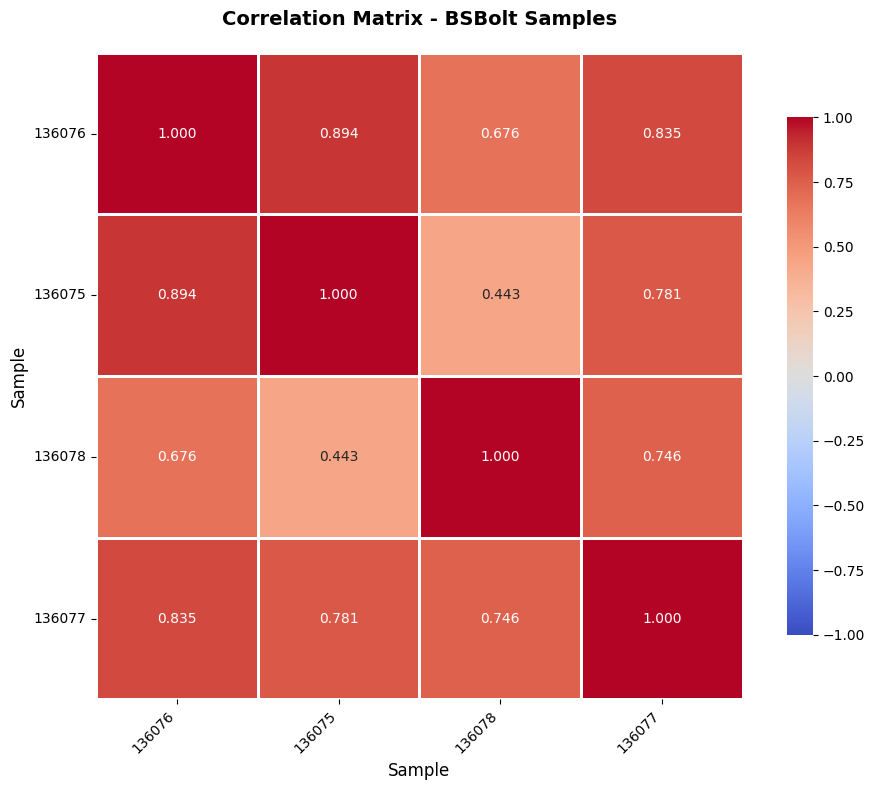

In [428]:
# Create a matrix from the data
samples = list(data.keys())
n_samples = len(samples)

# Calculate correlation matrix
correlation_matrix = np.zeros((n_samples, n_samples))
for i, sample1 in enumerate(samples):
    for j, sample2 in enumerate(samples):
        if i == j:
            correlation_matrix[i, j] = 1.0
        else:
            corr, _ = pearsonr(data[sample1], data[sample2])
            correlation_matrix[i, j] = corr

# Simplify sample names for better display
sample_labels = [s.replace(".rmdup.bam", "").replace("AS-", "") for s in samples]

# Create the plot
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    xticklabels=sample_labels,
    yticklabels=sample_labels,
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=1,
    cbar_kws={"shrink": 0.8},
)

plt.title("Correlation Matrix - BSBolt Samples", fontsize=14, fontweight="bold", pad=20)
plt.xlabel("Sample", fontsize=12)
plt.ylabel("Sample", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

#### Manifold Hypothesis Check ####

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from sklearn.preprocessing import StandardScaler


def visualize_complete_analysis(
    # --- Data Group A: The Model Development Splits ---
    train_features,  # (N_train, 39)
    valid_features,  # (N_valid, 39)
    test_features,  # (N_test, 39)
    # --- Data Group B: The Hold-out Analysis ---
    train_proportions,  # (N_train, 39)
    real_features,  # (4, 39) - The Biological Samples
    # sim_features_dict: keys should be 'train', 'valid', 'test'
    # values should be arrays of shape (4, 39) corresponding to the 4 real samples
    sim_features_dict,
    real_proportions,  # (4, 39)
    sample_names=None,
):

    if sample_names is None:
        sample_names = [f"Sample {i+1}" for i in range(len(real_features))]

    fig, axes = plt.subplots(1, 3, figsize=(24, 8))

    # ---------------------------------------------------------
    # SHARED PRE-PROCESSING
    # ---------------------------------------------------------
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(train_features)
    X_valid_scaled = scaler.transform(valid_features)
    X_test_scaled = scaler.transform(test_features)
    X_real_scaled = scaler.transform(real_features)

    # Prepare Sim Data Dictionary for projection
    sim_scaled_dict = {}
    for split_name, features in sim_features_dict.items():
        sim_scaled_dict[split_name] = scaler.transform(features)

    # Fit UMAP on Training Features ONLY
    reducer_feat = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=42)
    embedding_train = reducer_feat.fit_transform(X_train_scaled)

    # Project others
    embedding_valid = reducer_feat.transform(X_valid_scaled)
    embedding_test = reducer_feat.transform(X_test_scaled)
    embedding_real = reducer_feat.transform(X_real_scaled)

    # Project Sim Splits
    embedding_sim_dict = {}
    for split_name, scaled_feats in sim_scaled_dict.items():
        embedding_sim_dict[split_name] = reducer_feat.transform(scaled_feats)

    # ---------------------------------------------------------
    # PLOT 1: Model Splits (The Confetti Check)
    # ---------------------------------------------------------
    ax = axes[0]

    def sub(arr, n=5000):
        if len(arr) > n:
            idx = np.random.choice(len(arr), n, replace=False)
            return arr[idx]
        return arr

    ax.scatter(
        sub(embedding_train)[:, 0],
        sub(embedding_train)[:, 1],
        c="lightgrey",
        s=10,
        alpha=0.4,
        label="Train Split",
    )
    ax.scatter(
        sub(embedding_valid)[:, 0],
        sub(embedding_valid)[:, 1],
        c="teal",
        s=10,
        alpha=0.4,
        label="Valid Split",
    )
    ax.scatter(
        sub(embedding_test)[:, 0],
        sub(embedding_test)[:, 1],
        c="coral",
        s=10,
        alpha=0.4,
        label="Test Split",
    )

    ax.set_title(
        "1. Training Data Splits\n(Check for bias/leakage)",
        fontsize=14,
        fontweight="bold",
    )
    ax.legend()
    ax.axis("off")

    # ---------------------------------------------------------
    # PLOT 2: Domain Shift & Simulation Stability
    # ---------------------------------------------------------
    ax = axes[1]

    # Background
    ax.scatter(
        embedding_train[:, 0],
        embedding_train[:, 1],
        c="whitesmoke",
        s=5,
        alpha=0.5,
        label="Training Universe",
    )  # Lighter background

    colors = plt.cm.tab10(np.linspace(0, 1, len(real_features)))

    # Markers for the simulation splits
    markers = {"train": "o", "valid": "^", "test": "s"}

    for i, name in enumerate(sample_names):
        # 1. Plot Real Anchor (Star)
        real_x, real_y = embedding_real[i, 0], embedding_real[i, 1]
        ax.scatter(
            real_x,
            real_y,
            color=colors[i],
            marker="*",
            s=400,
            edgecolors="black",
            zorder=10,
            label=f"{name} (Real)" if i < 4 else "",
        )

        # 2. Plot Sim Variants and Connect Lines
        for split_name, embedding in embedding_sim_dict.items():
            sim_x, sim_y = embedding[i, 0], embedding[i, 1]

            # Plot Sim Point
            # Only label the first occurrence to keep legend clean
            label = f"Sim ({split_name})" if i == 0 else ""
            ax.scatter(
                sim_x,
                sim_y,
                color=colors[i],
                marker=markers[split_name],
                s=100,
                edgecolors="black",
                alpha=0.8,
                zorder=10,
                label=label,
            )

            # Draw Line from Real to Sim
            ax.plot(
                [real_x, sim_x],
                [real_y, sim_y],
                color=colors[i],
                linestyle="-",
                linewidth=0.8,
                alpha=0.5,
                zorder=5,
            )

    ax.set_title(
        "2. Domain Shift & Sim Stability\n(Star=Real, Shapes=Sim Splits)",
        fontsize=14,
        fontweight="bold",
    )

    # Custom Legend handling
    # We want to show colors for samples, and shapes for splits.
    # This can get messy, so we rely on the visual grouping.
    # A simplified legend is usually better here.
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(
        by_label.values(),
        by_label.keys(),
        loc="upper right",
        fontsize="x-small",
        framealpha=0.9,
    )
    ax.axis("off")

    # ---------------------------------------------------------
    # PLOT 3: Output Proportion Manifold
    # ---------------------------------------------------------
    ax = axes[2]
    reducer_prop = umap.UMAP(
        n_neighbors=30, min_dist=0.1, metric="manhattan", random_state=42
    )
    embedding_train_prop = reducer_prop.fit_transform(train_proportions)
    embedding_real_prop = reducer_prop.transform(real_proportions)

    ax.scatter(
        embedding_train_prop[:, 0],
        embedding_train_prop[:, 1],
        c="navajowhite",
        s=5,
        alpha=0.3,
        label="Training Mixtures",
    )

    for i, name in enumerate(sample_names):
        ax.scatter(
            embedding_real_prop[i, 0],
            embedding_real_prop[i, 1],
            color=colors[i],
            marker="D",
            s=150,
            edgecolors="black",
            label=f"{name} (GT)",
        )

    ax.set_title(
        "3. Biological Coverage\n(Target Composition)", fontsize=14, fontweight="bold"
    )
    ax.legend(loc="upper right", fontsize="small")
    ax.axis("off")

    plt.tight_layout()
    plt.show()

In [41]:
train_features_umap = np.array(
    [
        np.concat([np.diag(train_features[i]), train_features[i, :, -1]])
        for i in range(len(train_features))
    ]
)
valid_features_umap = np.array(
    [
        np.concat([np.diag(valid_features[i]), valid_features[i, :, -1]])
        for i in range(len(valid_features))
    ]
)
test_features_umap = np.array(
    [
        np.concat([np.diag(test_features[i]), test_features[i, :, -1]])
        for i in range(len(test_features))
    ]
)

In [42]:
real_features = []
for x in out_of_bag_deconv_inputs.values():
    sub = x[[f"prediction_{i}_wavg" for i in range(40)]]
    real_features.append(np.concat([np.diag(sub), sub.to_numpy()[:, -1]]))
real_features = np.array(real_features)

In [43]:
real_proportions = []
for key in uxm_res_dict.keys():
    uxm_preds = deepcopy(uxm_res_dict[key])
    uxm_preds = np.array([uxm_preds[key] for key in labels_dict.values()])
    real_proportions.append(uxm_preds)
real_proportions = np.array(real_proportions)

In [44]:
sim_feats = defaultdict(list)
splits = ["train", "valid", "test"]
for key in sim_features_dict.keys():
    for i in range(3):
        sub = sim_features_dict[key][i][[f"prediction_{i}_wavg" for i in range(40)]]
        feat_vec = np.concat([np.diag(sub), sub.to_numpy()[:, -1]])
        sim_feats[splits[i]].append(feat_vec.tolist())

for key in sim_feats.keys():
    sim_feats[key] = np.array(sim_feats[key])

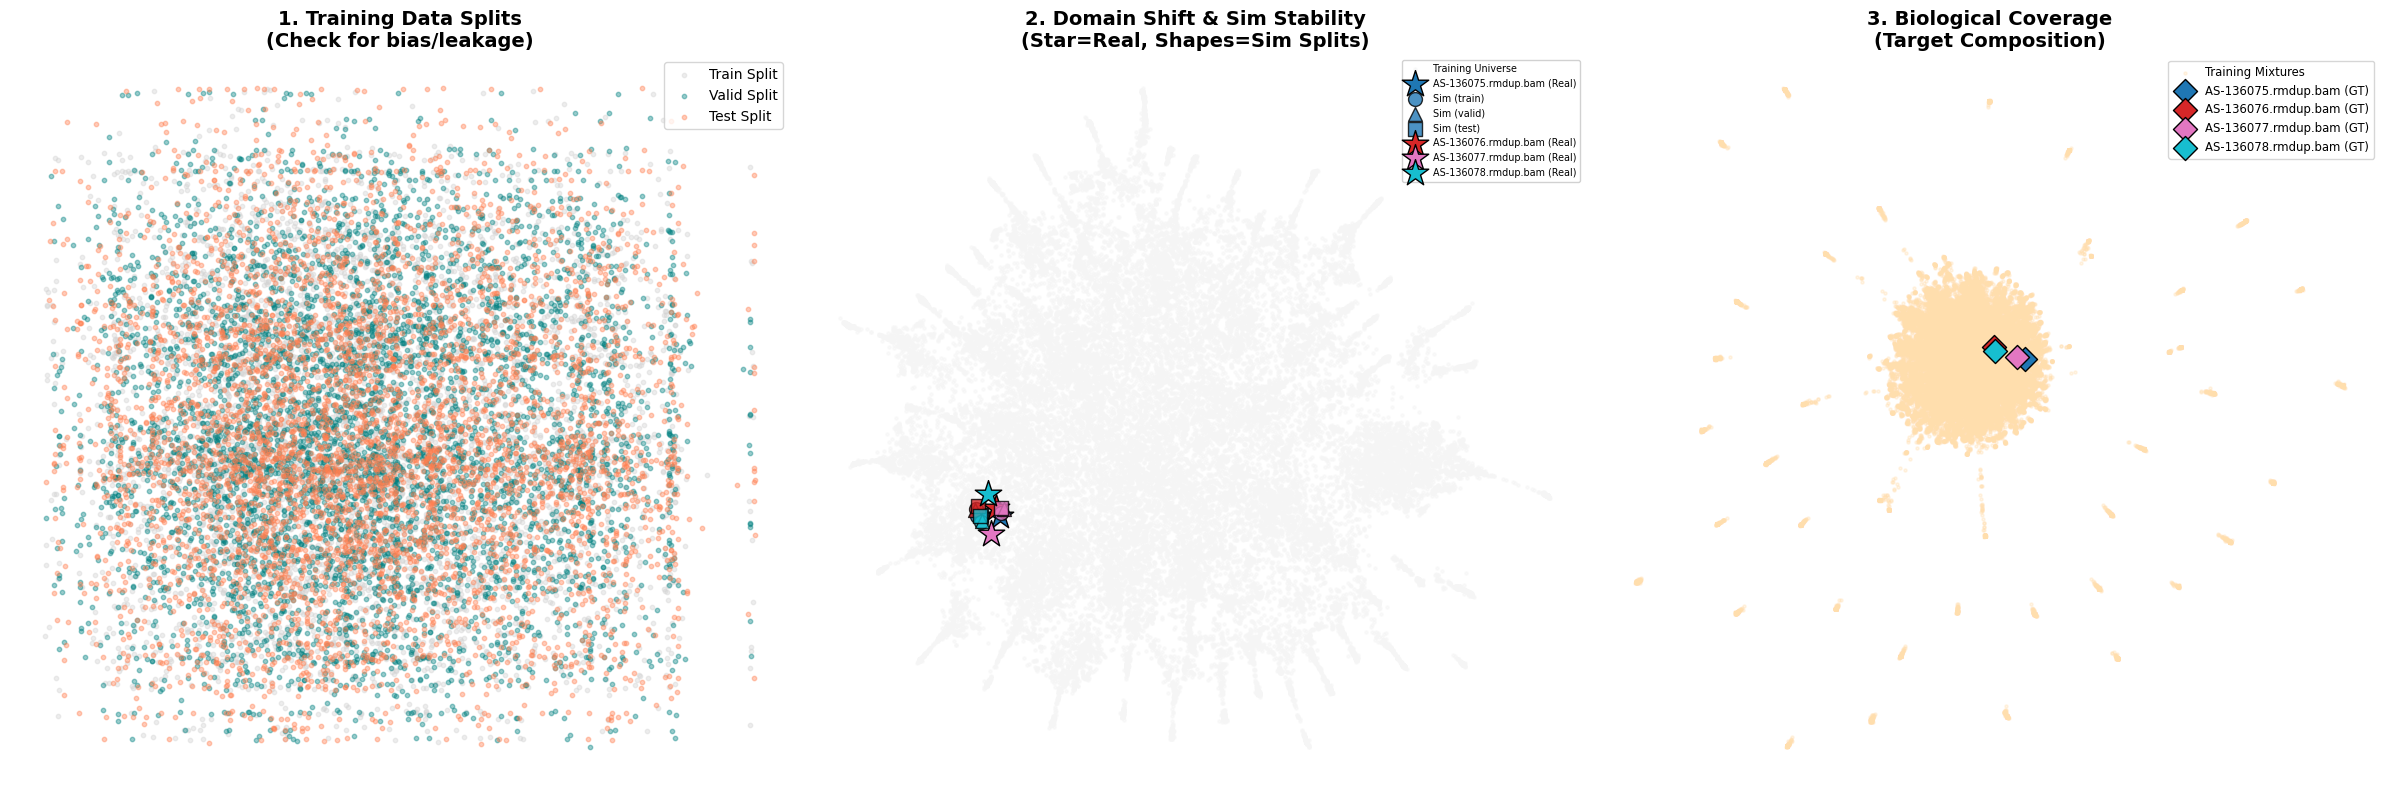

In [45]:
visualize_complete_analysis(
    train_features_umap,
    valid_features_umap,
    test_features_umap,
    train_outputs,
    sim_features_dict=sim_feats,
    real_features=real_features,
    real_proportions=real_proportions,
    sample_names=uxm_res_dict.keys(),
)

In [46]:
test_kls = []
for i in range(len(all_targets)):
    all_targets
    target_safe = np.clip(all_targets[i], eps, None)
    pred_safe = np.clip(all_preds[i], eps, None)
    kl = (target_safe * (np.log(target_safe) - np.log(pred_safe))).sum(axis=-1).mean()
    test_kls.append(kl)

test_kls = np.array(test_kls)

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import umap
from sklearn.preprocessing import StandardScaler


def visualize_zoomed_and_error(
    # --- Data for the Manifold ---
    train_features,
    test_features,
    test_kl_scores,
    # --- Data for the Specific Samples ---
    real_features,
    sim_features_dict,
    sample_names=None,
):

    if sample_names is None:
        sample_names = [f"Sample {i+1}" for i in range(len(real_features))]

    # 1. Preprocessing
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(train_features)
    X_test_scaled = scaler.transform(test_features)
    X_real_scaled = scaler.transform(real_features)

    # Fit UMAP on Train
    reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=42)
    embedding_train = reducer.fit_transform(X_train_scaled)

    # Transform Test and Real/Sim
    embedding_test = reducer.transform(X_test_scaled)
    embedding_real = reducer.transform(X_real_scaled)

    embedding_sim_dict = {}
    for k, v in sim_features_dict.items():
        embedding_sim_dict[k] = reducer.transform(scaler.transform(v))

    fig, axes = plt.subplots(1, 2, figsize=(22, 9))

    # =======================================================
    # PLOT 1: Hexbin Error Surface (Aggregation)
    # =======================================================
    ax = axes[0]

    # Use hexbin to aggregate.
    # C=test_kl_scores tells it to use KL values.
    # reduce_C_function=np.mean calculates the AVERAGE error in that hexagon.
    # gridsize=30 determines resolution (higher = finer bins).
    hb = ax.hexbin(
        embedding_test[:, 0],
        embedding_test[:, 1],
        C=test_kl_scores,
        gridsize=35,
        cmap="magma_r",
        reduce_C_function=np.mean,
        mincnt=1,  # Only plot bins with at least 1 point
        edgecolors="none",
    )

    # Add colorbar for the Mean Error
    cbar = plt.colorbar(hb, ax=ax)
    cbar.set_label("Mean KL Divergence (Lower = Better)")

    # --- Visualizing Density (Optional Contour) ---
    # Sometimes it's nice to see where the BULK of data is, regardless of error.
    # We overlay density contours (kdeplot style) in thin grey lines.
    # Note: If seaborn is slow with huge data, skip this block.
    import seaborn as sns

    try:
        sns.kdeplot(
            x=embedding_test[:, 0],
            y=embedding_test[:, 1],
            ax=ax,
            color="grey",
            linewidths=1,
            alpha=0.8,
            levels=10,
        )
    except:
        pass  # Fallback if singular matrix or other kde issues

    # --- Draw Target Regions (Ellipses) ---
    x_span = embedding_test[:, 0].max() - embedding_test[:, 0].min()
    y_span = embedding_test[:, 1].max() - embedding_test[:, 1].min()
    ell_width = x_span * 0.05
    ell_height = y_span * 0.05

    for i in range(len(real_features)):
        ell = Ellipse(
            xy=(embedding_real[i, 0], embedding_real[i, 1]),
            width=ell_width,
            height=ell_height,
            edgecolor="cyan",
            facecolor="none",  # Cyan stands out against magma
            linestyle="--",
            linewidth=2,
            label="My Targets" if i == 0 else "",
        )
        ax.add_patch(ell)
        ax.scatter(
            embedding_real[i, 0],
            embedding_real[i, 1],
            marker="+",
            color="cyan",
            s=60,
            linewidth=2,
        )

    ax.set_title(
        "1. Error & Density Map (Hexbin Aggregation)\n(Color = Mean Error in Region)",
        fontsize=14,
    )
    ax.legend(loc="upper right")
    ax.axis("off")
    # Invert axis so background matches standard plots (white=empty)
    ax.set_facecolor("whitesmoke")

    # =======================================================
    # PLOT 2: The Zoomed-In Analysis (Unchanged)
    # =======================================================
    ax = axes[1]

    # Background (lighter alpha)
    ax.scatter(
        embedding_test[:, 0], embedding_test[:, 1], c="lightgrey", s=10, alpha=0.1
    )

    colors = plt.cm.tab10(np.linspace(0, 1, len(real_features)))
    markers = {"train": "o", "valid": "^", "test": "s"}

    all_x = []
    all_y = []

    for i, name in enumerate(sample_names):
        rx, ry = embedding_real[i, 0], embedding_real[i, 1]
        ax.scatter(
            rx,
            ry,
            color=colors[i],
            marker="*",
            s=600,
            edgecolors="black",
            zorder=10,
            label=f"{name}",
        )
        all_x.append(rx)
        all_y.append(ry)

        for split, emb in embedding_sim_dict.items():
            sx, sy = emb[i, 0], emb[i, 1]
            ax.scatter(
                sx,
                sy,
                color=colors[i],
                marker=markers[split],
                s=150,
                edgecolors="black",
                alpha=0.8,
                zorder=10,
            )
            ax.plot([rx, sx], [ry, sy], color=colors[i], linestyle="-", lw=1, alpha=0.5)
            all_x.append(sx)
            all_y.append(sy)

    min_x, max_x = min(all_x), max(all_x)
    min_y, max_y = min(all_y), max(all_y)
    pad_x = (max_x - min_x) * 0.2 if (max_x - min_x) > 0 else 1.0
    pad_y = (max_y - min_y) * 0.2 if (max_y - min_y) > 0 else 1.0

    ax.set_xlim(min_x - pad_x, max_x + pad_x)
    ax.set_ylim(min_y - pad_y, max_y + pad_y)

    ax.set_title("2. Zoomed-In Stability Check\n(Spider Plot)", fontsize=14)
    ax.legend(loc="upper right", fontsize="small")

    plt.tight_layout()
    plt.show()

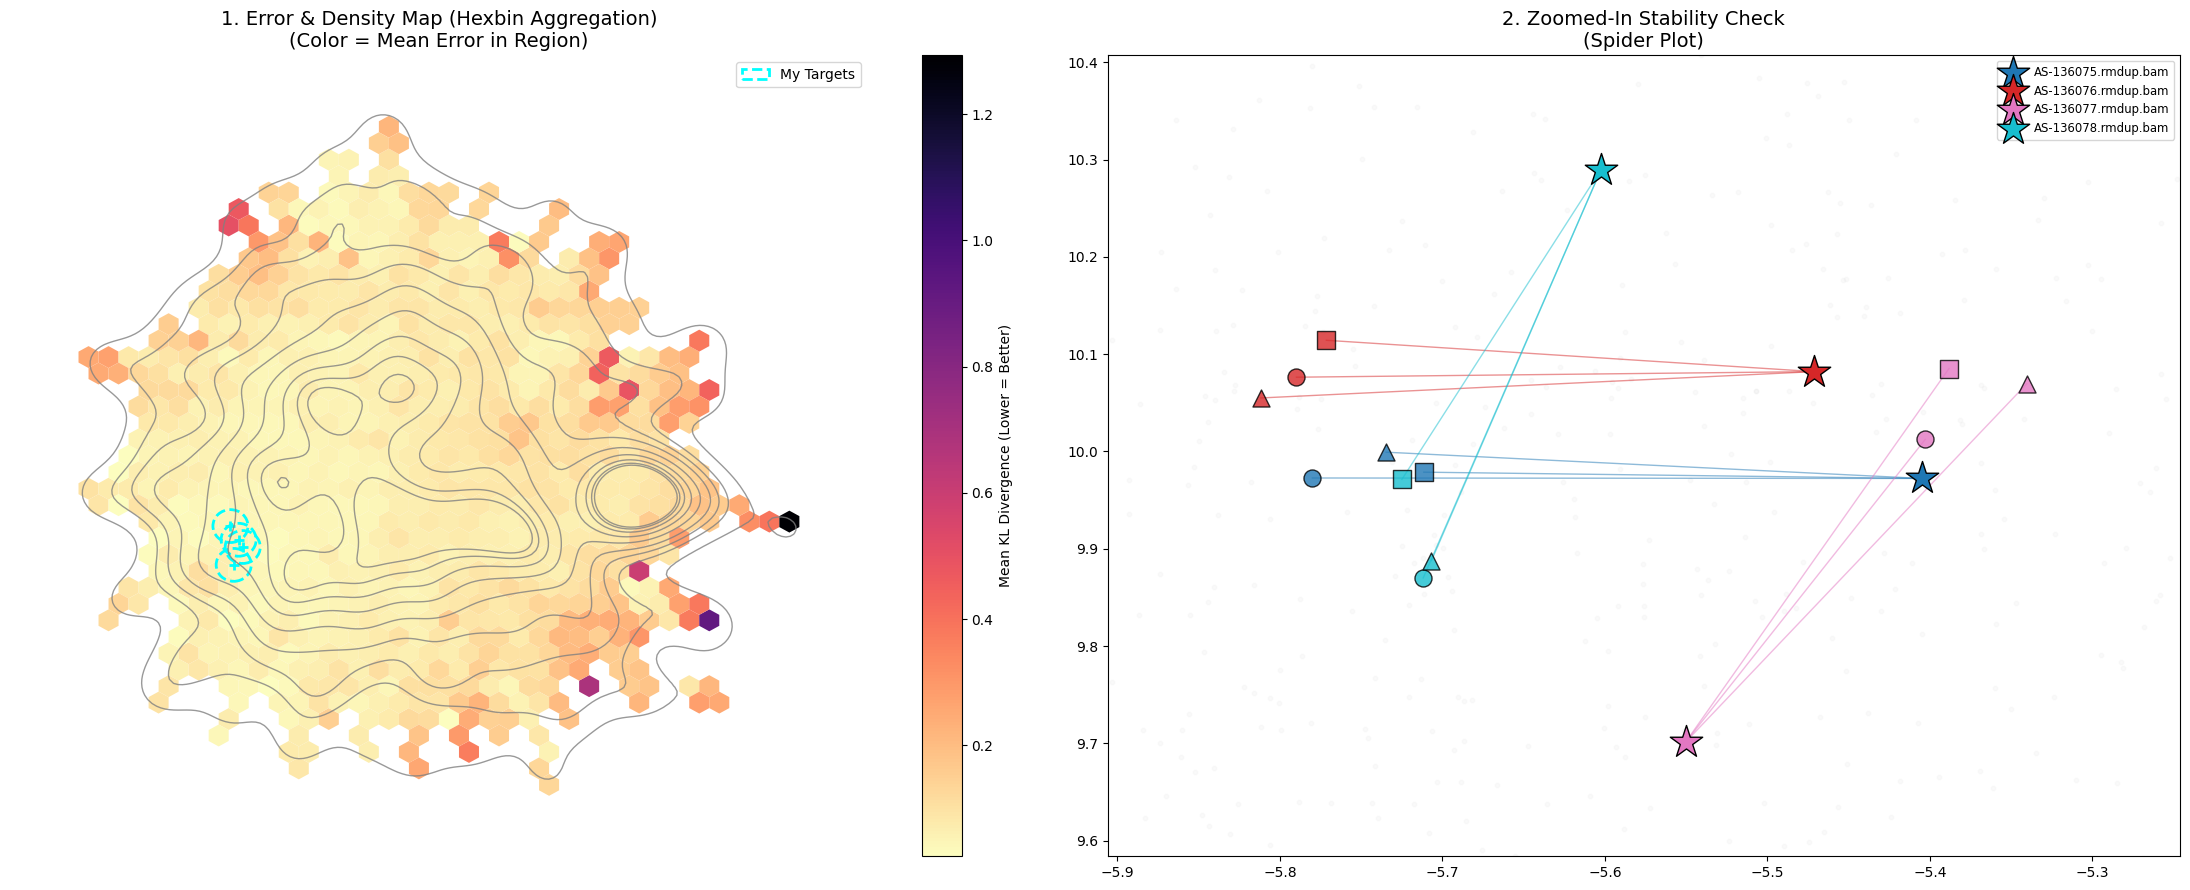

In [48]:
visualize_zoomed_and_error(
    train_features_umap,
    test_features_umap,
    test_kls,
    real_features,
    sim_feats,
    sample_names=uxm_res_dict.keys(),
)

### Check methylation levels correspondance

In [159]:
n_read_per_split = 300_000
simulated_bulks = defaultdict(lambda: defaultdict(list))
for key in deconv_results["mlp"].keys():
    key = str(key)
    target_proportions = deconv_results["mlp"][key]
    target_proportions = target_proportions / sum(target_proportions)

    xgb_target_proportions = deconv_results["XGB"][key]
    xgb_target_proportions = xgb_target_proportions / sum(xgb_target_proportions)

    mlp3l_proportions = deconv_results["mlp3l"][key]
    mlp3l_proportions = mlp3l_proportions / sum(mlp3l_proportions)

    uxm_preds = deepcopy(uxm_res_dict[key])
    uxm_preds = np.array([uxm_preds[key] for key in labels_dict.values()])
    uxm_proportions = uxm_preds / sum(uxm_preds)
    labels = range(40)
    _, _, _, _, reads_mlp = generate_pseudo_bulk(
        n_read_per_split,
        labels,
        target_proportions,
        train_split_uxm_input,
        valid_split_uxm_input,
        test_split_uxm_input,
        atlas,
        ref_cells,
        labels_dict_reversed,
        return_reads=True,
    )
    _, _, _, _, reads_uxm = generate_pseudo_bulk(
        n_read_per_split,
        labels,
        uxm_proportions,
        train_split_uxm_input,
        valid_split_uxm_input,
        test_split_uxm_input,
        atlas,
        ref_cells,
        labels_dict_reversed,
        return_reads=True,
    )
    _, _, _, _, reads_xgb = generate_pseudo_bulk(
        n_read_per_split,
        labels,
        xgb_target_proportions,
        train_split_uxm_input,
        valid_split_uxm_input,
        test_split_uxm_input,
        atlas,
        ref_cells,
        labels_dict_reversed,
        return_reads=True,
    )
    _, _, _, _, reads_mlp3l = generate_pseudo_bulk(
        n_read_per_split,
        labels,
        mlp3l_proportions,
        train_split_uxm_input,
        valid_split_uxm_input,
        test_split_uxm_input,
        atlas,
        ref_cells,
        labels_dict_reversed,
        return_reads=True,
    )

    simulated_bulks[key]["mlp"] = reads_mlp
    simulated_bulks[key]["uxm"] = reads_uxm
    simulated_bulks[key]["xgb"] = reads_xgb
    simulated_bulks[key]["mlp3l"] = reads_mlp3l

In [160]:
def get_atlas_methyl_rates(reads_df, target_name="MethylationRate"):
    res = (
        reads_df[
            ["name", "methylated_CpGs", "unmethylated_CpGs", "total_methylated_labels"]
        ]
        .groupby("name")
        .agg("sum")
        .reset_index()
    )
    res["MethylationRate"] = res["methylated_CpGs"] / res["total_methylated_labels"]
    res.rename(columns={"MethylationRate": target_name}, inplace=True)
    return res[["name", target_name]]

In [165]:
from functools import reduce

methylrates = defaultdict(pd.DataFrame)
for key in deconv_results["mlp"].keys():
    target_sub = deepcopy(results_for_methylbert[results_for_methylbert["file"] == key])
    target_sub.rename(
        columns={
            "M": "methylated_CpGs",
            "U": "unmethylated_CpGs",
            "NCPGS": "total_methylated_labels",
        },
        inplace=True,
    )
    target = get_atlas_methyl_rates(target_sub, "BSBolt")

    uxm_train = get_atlas_methyl_rates(simulated_bulks[key]["uxm"][0], "sim_uxm_train")
    uxm_valid = get_atlas_methyl_rates(simulated_bulks[key]["uxm"][1], "sim_uxm_valid")
    uxm_test = get_atlas_methyl_rates(simulated_bulks[key]["uxm"][2], "sim_uxm_test")

    oneHmlp_train = get_atlas_methyl_rates(
        simulated_bulks[key]["mlp"][0], "sim_oneHmlp_train"
    )
    oneHmlp_valid = get_atlas_methyl_rates(
        simulated_bulks[key]["mlp"][1], "sim_oneHmlp_valid"
    )
    oneHmlp_test = get_atlas_methyl_rates(
        simulated_bulks[key]["mlp"][2], "sim_oneHmlp_test"
    )

    xgb_train = get_atlas_methyl_rates(simulated_bulks[key]["xgb"][0], "sim_xgb_train")
    xgb_valid = get_atlas_methyl_rates(simulated_bulks[key]["xgb"][1], "sim_xgb_valid")
    xgb_test = get_atlas_methyl_rates(simulated_bulks[key]["xgb"][2], "sim_xgb_test")

    threeMLP_train = get_atlas_methyl_rates(
        simulated_bulks[key]["mlp3l"][0], "sim_threeMLP_train"
    )
    threeMLP_valid = get_atlas_methyl_rates(
        simulated_bulks[key]["mlp3l"][1], "sim_threeMLP_valid"
    )
    threeMLP_test = get_atlas_methyl_rates(
        simulated_bulks[key]["mlp3l"][2], "sim_threeMLP_test"
    )

    df_merged = reduce(
        lambda left, right: pd.merge(left, right, on=["name"], how="outer"),
        [
            target,
            uxm_train,
            uxm_valid,
            uxm_test,
            oneHmlp_train,
            oneHmlp_valid,
            oneHmlp_test,
            xgb_train,
            xgb_valid,
            xgb_test,
            threeMLP_train,
            threeMLP_valid,
            threeMLP_test,
        ],
    )
    methylrates[key] = df_merged

In [171]:
methylrates.keys()

dict_keys(['AS-136076.rmdup.bam', 'AS-136075.rmdup.bam', 'AS-136078.rmdup.bam', 'AS-136077.rmdup.bam'])

In [ ]:
data = methylrates["AS-136078.rmdup.bam"].dropna().to_dict(orient="records")
df = pd.DataFrame(data)
df = df[
    df["name"].apply(
        lambda x: x in atlas["name"][atlas["target"] == "Adipocytes"].to_list()
    )
]

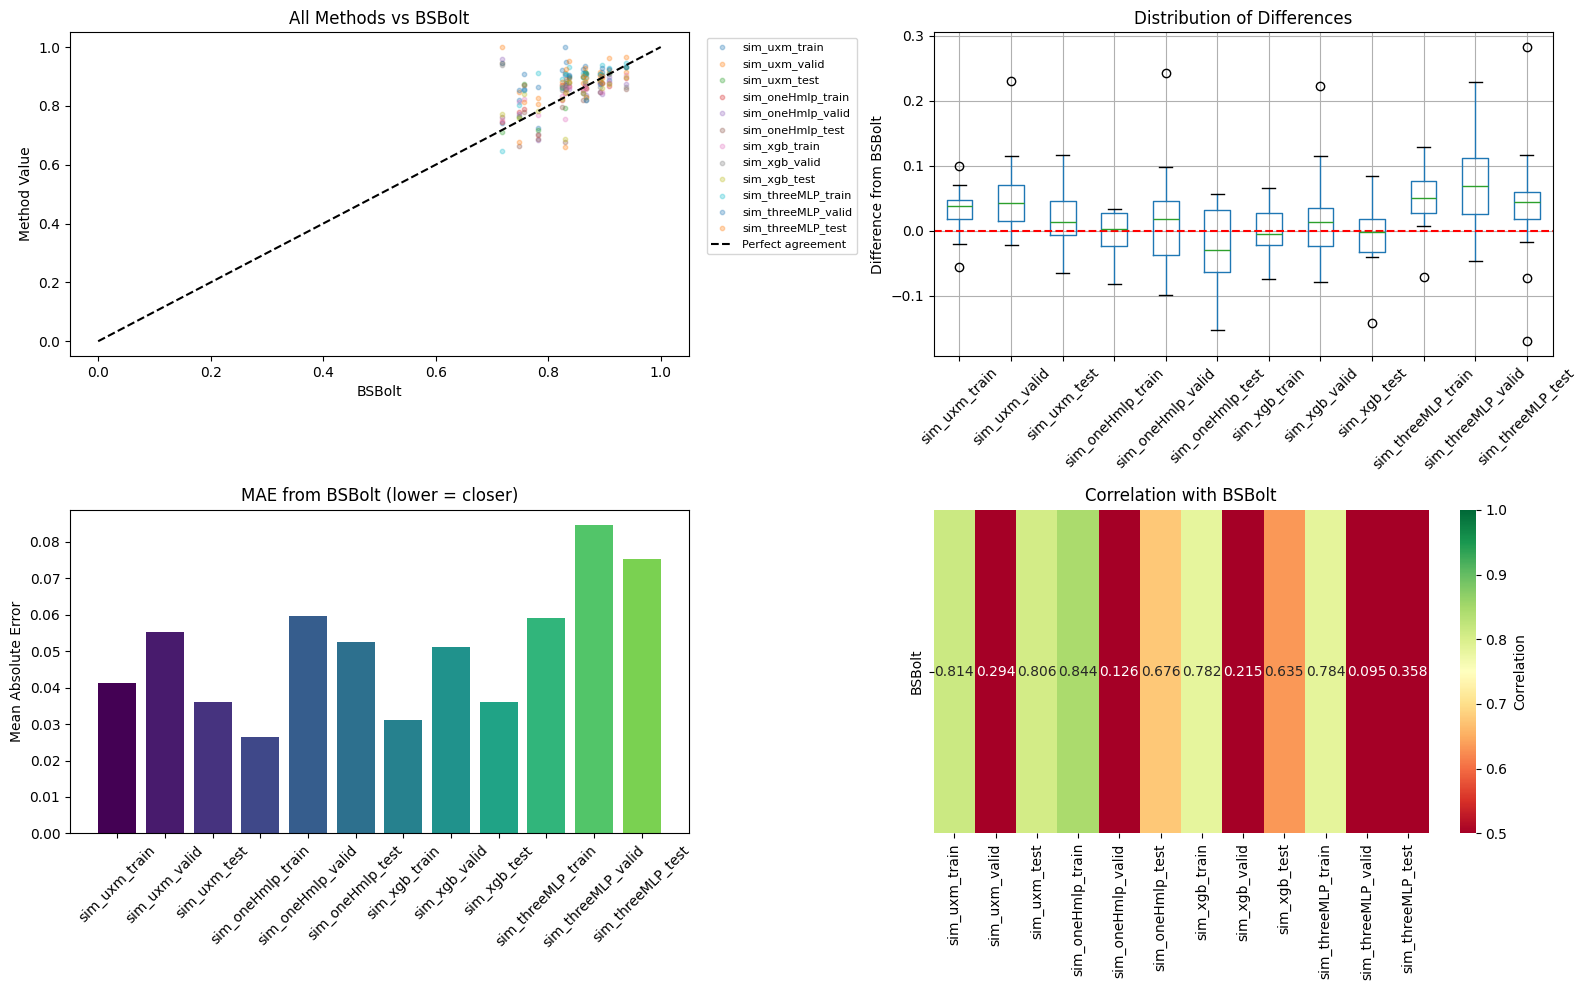


=== Summary Statistics ===

Correlation with BSBolt:
sim_oneHmlp_train     0.843870
sim_uxm_train         0.813831
sim_uxm_test          0.806453
sim_threeMLP_train    0.783575
sim_xgb_train         0.782062
sim_oneHmlp_test      0.675909
sim_xgb_test          0.634578
sim_threeMLP_test     0.357773
sim_uxm_valid         0.294180
sim_xgb_valid         0.215470
sim_oneHmlp_valid     0.126495
sim_threeMLP_valid    0.095056
Name: BSBolt, dtype: float64

Mean Absolute Error:
sim_oneHmlp_train     0.026525
sim_xgb_train         0.031051
sim_uxm_test          0.036022
sim_xgb_test          0.036113
sim_uxm_train         0.041237
sim_xgb_valid         0.051061
sim_oneHmlp_test      0.052628
sim_uxm_valid         0.055161
sim_threeMLP_train    0.059170
sim_oneHmlp_valid     0.059575
sim_threeMLP_test     0.075422
sim_threeMLP_valid    0.084606
dtype: float64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Columns to compare against BSBolt
methods = [
    "sim_uxm_train",
    "sim_uxm_valid",
    "sim_uxm_test",
    "sim_oneHmlp_train",
    "sim_oneHmlp_valid",
    "sim_oneHmlp_test",
    "sim_xgb_train",
    "sim_xgb_valid",
    "sim_xgb_test",
    "sim_threeMLP_train",
    "sim_threeMLP_valid",
    "sim_threeMLP_test",
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Scatter plots with regression lines
ax1 = axes[0, 0]
for method in methods:
    ax1.scatter(df["BSBolt"], df[method], alpha=0.3, label=method, s=10)
ax1.plot([0, 1], [0, 1], "k--", label="Perfect agreement")
ax1.set_xlabel("BSBolt")
ax1.set_ylabel("Method Value")
ax1.set_title("All Methods vs BSBolt")
ax1.legend(bbox_to_anchor=(1.02, 1), fontsize=8)

# 2. Box plot of differences (method - BSBolt)
ax2 = axes[0, 1]
differences = pd.DataFrame({method: df[method] - df["BSBolt"] for method in methods})
differences.boxplot(ax=ax2)
ax2.axhline(y=0, color="r", linestyle="--")
ax2.set_ylabel("Difference from BSBolt")
ax2.set_title("Distribution of Differences")
ax2.tick_params(axis="x", rotation=45)

# 3. Mean Absolute Error bar chart
ax3 = axes[1, 0]
mae = {method: np.abs(df[method] - df["BSBolt"]).mean() for method in methods}
colors = plt.cm.viridis(np.linspace(0, 0.8, len(methods)))
bars = ax3.bar(mae.keys(), mae.values(), color=colors)
ax3.set_ylabel("Mean Absolute Error")
ax3.set_title("MAE from BSBolt (lower = closer)")
ax3.tick_params(axis="x", rotation=45)

# 4. Correlation heatmap
ax4 = axes[1, 1]
corr_with_bsbolt = df[["BSBolt"] + methods].corr()["BSBolt"].drop("BSBolt")
corr_df = corr_with_bsbolt.to_frame().T
sns.heatmap(
    corr_df,
    annot=True,
    cmap="RdYlGn",
    vmin=0.5,
    vmax=1,
    ax=ax4,
    fmt=".3f",
    cbar_kws={"label": "Correlation"},
)
ax4.set_title("Correlation with BSBolt")

plt.tight_layout()
plt.savefig("bsbolt_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# Print summary statistics
print("\n=== Summary Statistics ===")
print("\nCorrelation with BSBolt:")
print(corr_with_bsbolt.sort_values(ascending=False))
print("\nMean Absolute Error:")
print(pd.Series(mae).sort_values())

In [247]:
data = methylrates["AS-136077.rmdup.bam"].dropna().to_dict(orient="records")
df = pd.DataFrame(data)

In [243]:
_, _, _, _, adipocytes = generate_pseudo_bulk(
    n_read_per_split,
    [19],
    [1.0],
    train_split_uxm_input,
    valid_split_uxm_input,
    test_split_uxm_input,
    atlas,
    ref_cells,
    labels_dict_reversed,
    return_reads=True,
)

In [244]:
adipocytes_train = get_atlas_methyl_rates(adipocytes[0], "adipocytes_train")
adipocytes_valid = get_atlas_methyl_rates(adipocytes[1], "adipocytes_valid")
adipocytes_test = get_atlas_methyl_rates(adipocytes[2], "adipocytes_test")

In [249]:
df = reduce(
    lambda left, right: pd.merge(left, right, on=["name"], how="outer"),
    [df, adipocytes_train, adipocytes_valid, adipocytes_test],
)

In [250]:
df = df[
    df["name"].apply(
        lambda x: x in atlas["name"][atlas["target"] == "Adipocytes"].to_list()
    )
]

In [252]:
df.dropna(inplace=True)

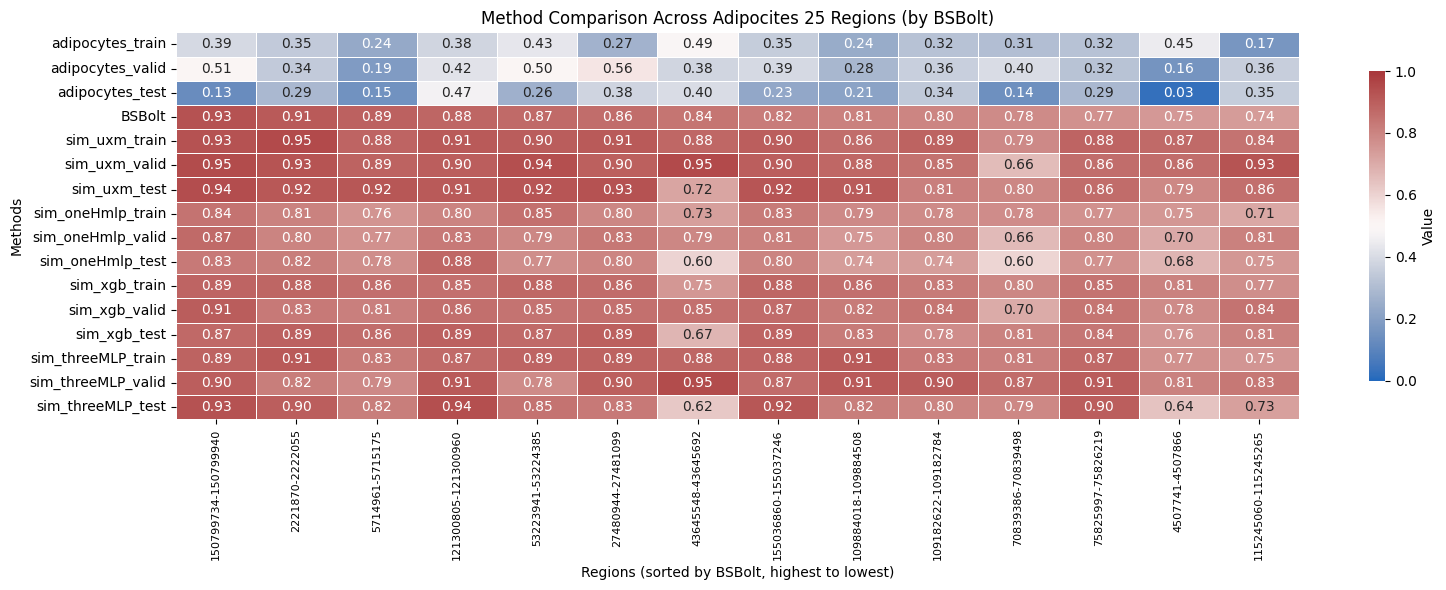

In [253]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Methods to display (rows in heatmap)
methods = [
    "adipocytes_train",
    "adipocytes_valid",
    "adipocytes_test",
    "BSBolt",
    "sim_uxm_train",
    "sim_uxm_valid",
    "sim_uxm_test",
    "sim_oneHmlp_train",
    "sim_oneHmlp_valid",
    "sim_oneHmlp_test",
    "sim_xgb_train",
    "sim_xgb_valid",
    "sim_xgb_test",
    "sim_threeMLP_train",
    "sim_threeMLP_valid",
    "sim_threeMLP_test",
]

# Sort by BSBolt value
df_sorted = df.sort_values("BSBolt", ascending=False)

# Select top N regions (adjust as needed, max 25)
n_regions = 25
df_subset = df_sorted.head(n_regions)

# Prepare data for heatmap: transpose so methods are rows, regions are columns
heatmap_data = df_subset.set_index("name")[methods].T

# Shorten region names for display (optional - shows just the position)
short_names = [
    name.split(":")[1] if ":" in name else name for name in heatmap_data.columns
]

# Create the heatmap
fig, ax = plt.subplots(figsize=(16, 6))

sns.heatmap(
    heatmap_data,
    annot=True,  # Show values in cells
    fmt=".2f",  # 2 decimal places
    cmap="vlag",  # Red-Yellow-Green colormap (low=red, high=green)
    vmin=0,  # Adjust based on your data range
    vmax=1.0,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Value", "shrink": 0.8},
    ax=ax,
)

# Set shortened column labels
ax.set_xticklabels(short_names, rotation=90, ha="center", fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

ax.set_xlabel("Regions (sorted by BSBolt, highest to lowest)")
ax.set_ylabel("Methods")
ax.set_title(f"Method Comparison Across Adipocites {n_regions} Regions (by BSBolt)")

plt.tight_layout()
plt.savefig("heatmap_methods_vs_regions.png", dpi=150, bbox_inches="tight")
plt.show()